In [ ]:
# Install Python libraries
! pip3 install numpy==1.23.5
! pip3 install pandas==2.0.1
! pip3 install networkx==3.3.0
! pip3 install bokeh==3.0.3
! pip3 install stream==1.0.0
! pip3 install selenium==4.33.0

# 1. Library and settings

In [2]:
# Library
import os
import pickle
import networkx as nx
import pandas as pd
import numpy as np
import stream as st
st.__version__

'1.0'

In [ ]:
from bokeh.models import Band, ColumnDataSource
from bokeh.plotting import figure, show
from bokeh.io import output_notebook, show
from bokeh.models import ColumnDataSource, HoverTool, LinearColorMapper
from bokeh.plotting import figure
from bokeh.models import SaveTool
from bokeh.io import export_png
from bokeh.models import Range1d

In [ ]:
import linecache

In [3]:
# Figure number definitions
Fig2 = {}
for label in ['a', 'b', 'c', 'd', 'e', 'f', 'g']:
    Fig2[label] = f'Fig/Figure2({label})'

In [4]:
# Settings
st.set_figure_params(dpi=80,style='white',figsize=[16,12], rc={'image.cmap': 'viridis'})
pd.set_option('display.max_columns', 100)

# 2. Functions

In [5]:
# Modify STREAM source code to make linewidth and savepath adjustable.
from pandas.api.types import (
    is_string_dtype,
    is_numeric_dtype
)
import pylab as plt
import seaborn as sns
import matplotlib as mpl

from copy import deepcopy
from scipy import interpolate
import itertools
from scipy.signal import savgol_filter
from matplotlib.patches import Polygon


# Trajectory
def plot_dimension_reduction(
    adata,n_components = None,comp1=0,comp2=1,comp3=2,color=None,key_graph='epg',
    fig_size=None,fig_ncol=3,fig_legend_ncol=1,fig_legend_order = None,
    vmin=None,vmax=None,alpha=0.8,
    pad=1.08,w_pad=None,h_pad=None,
    show_text=False,show_graph=False,
    save_fig=False,fig_path=None,fig_name='dimension_reduction.pdf',
    plotly=False,
    line_width=3,
    text_fontsize=1
):
    """Plot the manifold where the graph is learned
    
    Parameters
    ----------
    adata: AnnData
        Annotated data matrix.
    n_components: `int`, optional (default: 3)
        Number of components to be plotted.
    comp1: `int`, optional (default: 0)
        Component used for x axis.
    comp2: `int`, optional (default: 1)
        Component used for y axis.
    comp3: `int`, optional (default: 2)
        Component used for z axis. (only valid when n_components=3)
    color: `list` optional (default: None)
        Column names of observations (adata.obs.columns) or variable names(adata.var_names). A list of names to be plotted. 
    key_graph: `str`, optional (default: None): 
        Choose from {{'epg','seed_epg','ori_epg'}}
        Specify gragh to be plotted.
        'epg' current elastic principal graph
        'seed_epg' seed structure used for elastic principal graph learning, which is obtained by running seed_elastic_principal_graph()
        'ori_epg' original elastic principal graph, which is obtained by running elastic_principal_graph()
    fig_size: `tuple`, optional (default: None)
        figure size.
    fig_ncol: `int`, optional (default: 3)
        the number of columns of the figure panel
    fig_legend_order: `dict`,optional (default: None)
        Specified order for the appearance of the annotation keys.Only valid for ategorical variable  
        e.g. fig_legend_order = {'ann1':['a','b','c'],'ann2':['aa','bb','cc']}
    fig_legend_ncol: `int`, optional (default: 1)
        The number of columns that the legend has.
    vmin,vmax: `float`, optional (default: None)
        The min and max values are used to normalize continuous values. If None, the respective min and max of continuous values is used.
    alpha: `float`, optional (default: 0.8)
        0.0 transparent through 1.0 opaque
    pad: `float`, optional (default: 1.08)
        Padding between the figure edge and the edges of subplots, as a fraction of the font size.
    h_pad, w_pad: `float`, optional (default: None)
        Padding (height/width) between edges of adjacent subplots, as a fraction of the font size. Defaults to pad.
    show_text: `bool`, optional (default: False)
        If True, node state label will be shown
    show_graph: `bool`, optional (default: False)
        If True, the learnt principal graph will be shown
    save_fig: `bool`, optional (default: False)
        if True,save the figure.
    fig_path: `str`, optional (default: None)
        if save_fig is True, specify figure path. if None, adata.uns['workdir'] will be used.
    fig_name: `str`, optional (default: 'dimension_reduction.pdf')
        if save_fig is True, specify figure name.
    plotly: `bool`, optional (default: False)
        if True, plotly will be used to make interactive plots 
    Returns
    -------
    None

    """

    if(fig_path is None):
        fig_path = adata.uns['workdir']
    fig_size = mpl.rcParams['figure.figsize'] if fig_size is None else fig_size

    if(n_components==None):
        n_components = min(3,adata.obsm['X_dr'].shape[1])
    if n_components not in [2,3]:
        raise ValueError("n_components should be 2 or 3")    
    if(n_components>adata.obsm['X_dr'].shape[1]):
        print("`n_components` is greater than the available dimension. It is corrected to %s" %adata.obsm['X_dr'].shape[1])
        n_components = adata.obsm['X_dr'].shape[1] 
        
    if(color is None):
        color = ['label']
    ###remove duplicate keys
    color = list(dict.fromkeys(color))     

    dict_ann = dict()
    for ann in color:
        if(ann in adata.obs.columns):
            dict_ann[ann] = adata.obs[ann]
        elif(ann in adata.var_names):
            dict_ann[ann] = adata.obs_vector(ann)
        else:
            raise ValueError("could not find '%s' in `adata.obs.columns` and `adata.var_names`"  % (ann))

    df_plot = pd.DataFrame(index=adata.obs.index,data = adata.obsm['X_dr'],columns=['Dim'+str(x+1) for x in range(adata.obsm['X_dr'].shape[1])])
    for ann in color:
        df_plot[ann] = dict_ann[ann]
    df_plot_shuf = df_plot.sample(frac=1,random_state=100)

    legend_order = {ann:np.unique(df_plot_shuf[ann]) for ann in color if is_string_dtype(df_plot_shuf[ann])}
    if(fig_legend_order is not None):
        if(not isinstance(fig_legend_order, dict)):
            raise TypeError("`fig_legend_order` must be a dictionary")
        for ann in fig_legend_order.keys():
            if(ann in legend_order.keys()):
                legend_order[ann] = fig_legend_order[ann]
            else:
                print("'%s' is ignored for ordering legend labels due to incorrect name or data type" % ann)

    if(show_graph or show_text):
        assert (all(np.isin(['epg','flat_tree'],adata.uns_keys()))),'''graph is not learnt yet. 
        please first run: `st.seed_elastic_principal_graph` and `st.elastic_principal_graph` to learn graph'''
        assert (key_graph in ['epg','seed_epg','ori_epg']),"key_graph must be one of ['epg','seed_epg','ori_epg']"    
        if(fig_path is None):
            fig_path = adata.uns['workdir']
        if(key_graph=='epg'):
            epg = adata.uns['epg']
            flat_tree = adata.uns['flat_tree']
        else:
            epg = adata.uns[key_graph.split('_')[0]+'_epg']
            flat_tree = adata.uns[key_graph.split('_')[0]+'_flat_tree']
        ft_node_pos = nx.get_node_attributes(flat_tree,'pos')
        ft_node_label = nx.get_node_attributes(flat_tree,'label')
        epg_node_pos = nx.get_node_attributes(epg,'pos')   

    if(plotly):
        for ann in color:
            if(n_components==3): 
                fig = px.scatter_3d(df_plot_shuf, x='Dim'+str(comp1+1), y='Dim'+str(comp2+1), z='Dim'+str(comp3+1),color=ann,
                                    opacity=alpha,
                                    color_continuous_scale=px.colors.sequential.Viridis,
                                    color_discrete_map=adata.uns[ann+'_color'] if ann+'_color' in adata.uns_keys() else {})
                fig.update_traces(marker=dict(size=2))
                if(show_graph):
                    for edge_i in flat_tree.edges():
                        branch_i_pos = np.array([epg_node_pos[i] for i in flat_tree.edges[edge_i]['nodes']])
                        edge_i_label = flat_tree.nodes[edge_i[0]]['label'] +'_'+flat_tree.nodes[edge_i[1]]['label']
                        curve_i = pd.DataFrame(branch_i_pos,columns=np.arange(branch_i_pos.shape[1]))
                        fig.add_trace(go.Scatter3d(x=curve_i[comp1], 
                                                   y=curve_i[comp2], 
                                                   z=curve_i[comp3],
                                                   mode='lines',
                                                   line=dict(color='black', width=3),
                                                   name=edge_i_label,
                                                   showlegend=True if is_string_dtype(df_plot[ann]) else False))                
                if(show_text):
                    fig.add_trace(go.Scatter3d(x=np.array(list(ft_node_pos.values()))[:,comp1], 
                                               y=np.array(list(ft_node_pos.values()))[:,comp2], 
                                               z=np.array(list(ft_node_pos.values()))[:,comp3],
                                               mode='markers+text',
                                               opacity=1,
                                               marker=dict(size=4,color='#767070'),
                                               text=[ft_node_label[x] for x in ft_node_pos.keys()],
                                               textposition="bottom center",
                                               name='states',
                                               showlegend=True if is_string_dtype(df_plot[ann]) else False))
                fig.update_layout(legend= {'itemsizing': 'constant'},width=500,height=500, 
                                  scene = dict(aspectmode='cube'))
            else:
                fig = px.scatter(df_plot_shuf, x='Dim'+str(comp1+1), y='Dim'+str(comp2+1),color=ann,
                                 opacity=alpha,
                                 color_continuous_scale=px.colors.sequential.Viridis,
                                 color_discrete_map=adata.uns[ann+'_color'] if ann+'_color' in adata.uns_keys() else {})
                if(show_graph):
                    for edge_i in flat_tree.edges():
                        branch_i_pos = np.array([epg_node_pos[i] for i in flat_tree.edges[edge_i]['nodes']])[:,[comp1,comp2]]
                        edge_i_label = flat_tree.nodes[edge_i[0]]['label'] +'_'+flat_tree.nodes[edge_i[1]]['label']
                        curve_i = pd.DataFrame(branch_i_pos,columns=np.arange(branch_i_pos.shape[1]))
                        fig.add_trace(go.Scatter(x=curve_i[comp1], 
                                                   y=curve_i[comp2],
                                                   mode='lines',
                                                   line=dict(color='black', width=3),
                                                   name=edge_i_label,
                                                   showlegend=True if is_string_dtype(df_plot[ann]) else False))
                if(show_text):
                    fig.add_trace(go.Scatter(x=np.array(list(ft_node_pos.values()))[:,comp1], 
                                               y=np.array(list(ft_node_pos.values()))[:,comp2], 
                                               mode='markers+text',
                                               opacity=1,
                                               marker=dict(size=1.5*mpl.rcParams['lines.markersize'],color='#767070'),
                                               text=[ft_node_label[x] for x in ft_node_pos.keys()],
                                               textposition="bottom center",
                                               name='states',
                                               showlegend=True if is_string_dtype(df_plot[ann]) else False))

                fig.update_layout(legend= {'itemsizing': 'constant'},width=500,height=500) 
            fig.show(renderer="notebook")
            
    else:
        if(len(color)<fig_ncol):
            fig_ncol=len(color)
        fig_nrow = int(np.ceil(len(color)/fig_ncol))
        fig = plt.figure(figsize=(fig_size[0]*fig_ncol*1.05,fig_size[1]*fig_nrow))
        for i,ann in enumerate(color):
            if(n_components==3):
                if(is_string_dtype(df_plot[ann])):
                    ### export colors and legend from 2D sns.scatterplot 
                    ax_i = fig.add_subplot(fig_nrow,fig_ncol,i+1)
                    sc_i=sns.scatterplot(ax=ax_i,
                                        x="Dim1", y="Dim2",
                                        hue=ann,hue_order = legend_order[ann],
                                        data=df_plot_shuf,
                                        alpha=alpha,linewidth=0,
                                        palette= adata.uns[ann+'_color'] \
                                                if (ann+'_color' in adata.uns_keys()) and (set(adata.uns[ann+'_color'].keys()) >= set(np.unique(df_plot_shuf[ann]))) \
                                                else None
                                        )             
                    colors_sns = sc_i.get_children()[0].get_facecolors()
                    if(ann+'_color' not in adata.uns_keys()):
                        colors_sns_scaled = (255*colors_sns).astype(int)
                        adata.uns[ann+'_color'] = {df_plot_shuf[ann][i]:'#%02x%02x%02x' % (colors_sns_scaled[i][0], colors_sns_scaled[i][1], colors_sns_scaled[i][2])
                                                   for i in np.unique(df_plot_shuf[ann],return_index=True)[1]}
                    legend_sns,labels_sns = ax_i.get_legend_handles_labels()
                    ax_i.remove()
                    ax_i = fig.add_subplot(fig_nrow,fig_ncol,i+1,projection='3d')
                    ax_i.scatter(df_plot_shuf['Dim'+str(comp1+1)], df_plot_shuf['Dim'+str(comp2+1)],df_plot_shuf['Dim'+str(comp3+1)],
                                 c=colors_sns,alpha=alpha,linewidth=0,
                                 zorder=-1)
                    ax_i.legend(legend_sns,labels_sns,bbox_to_anchor=(1.08, 0.5), loc='center left', ncol=fig_legend_ncol,
                                frameon=False,)                    
                    
                else:
                    ax_i = fig.add_subplot(fig_nrow,fig_ncol,i+1,projection='3d')
                    vmin_i = df_plot[ann].min() if vmin is None else vmin
                    vmax_i = df_plot[ann].max() if vmax is None else vmax
                    sc_i = ax_i.scatter(df_plot_shuf['Dim'+str(comp1+1)], 
                                        df_plot_shuf['Dim'+str(comp2+1)],
                                        df_plot_shuf['Dim'+str(comp3+1)],
                                        c=df_plot_shuf[ann],vmin=vmin_i,vmax=vmax_i,alpha=alpha,linewidth=0,
                                        zorder=-1)
                    cbar = plt.colorbar(sc_i,ax=ax_i, pad=0.1, fraction=0.05, aspect=30)
                    cbar.solids.set_edgecolor("face")
                    cbar.ax.locator_params(nbins=5)
                if(show_graph):
                    for edge_i in flat_tree.edges():
                        branch_i_pos = np.array([epg_node_pos[i] for i in flat_tree.edges[edge_i]['nodes']])
                        curve_i = pd.DataFrame(branch_i_pos,columns=np.arange(branch_i_pos.shape[1]))
                        ax_i.plot(curve_i[comp1],curve_i[comp2],curve_i[comp3],c = 'black',zorder=5)
                if(show_text):
                    for node_i in flat_tree.nodes():
                        ### matplotlib has zcorder issues for 3D plot.To avoid the incorrect order, here the node point is removed for 3D
                        # ax_i.scatter(ft_node_pos[node_i][comp1],ft_node_pos[node_i][comp2],ft_node_pos[node_i][comp3],
                        #              color='#767070',s=1.5*(mpl.rcParams['lines.markersize']**2),zorder=10)                  
                        ax_i.text(ft_node_pos[node_i][comp1],ft_node_pos[node_i][comp2],ft_node_pos[node_i][comp3],
                                  ft_node_label[node_i],
                                  color='black',fontsize=0.9*mpl.rcParams['font.size'],
                                  ha='left', va='bottom',
                                  zorder=10)                
                ax_i.set_xlabel('Dim'+str(comp1+1),labelpad=-5,rotation=-15)
                ax_i.set_ylabel('Dim'+str(comp2+1),labelpad=0,rotation=45)
                ax_i.set_zlabel('Dim'+str(comp3+1),labelpad=5,rotation=90)
                ax_i.locator_params(axis='x',nbins=4)
                ax_i.locator_params(axis='y',nbins=4)
                ax_i.locator_params(axis='z',nbins=4)
                ax_i.tick_params(axis="x",pad=-4)
                ax_i.tick_params(axis="y",pad=-1)
                ax_i.tick_params(axis="z",pad=3.5)
                ax_i.set_title(ann)
            else:
                ax_i = fig.add_subplot(fig_nrow,fig_ncol,i+1)
                if(is_string_dtype(df_plot[ann])):
                    sc_i=sns.scatterplot(ax=ax_i,
                                        x='Dim'+str(comp1+1), y='Dim'+str(comp2+1),
                                        hue=ann,hue_order = legend_order[ann],
                                        data=df_plot_shuf,
                                        alpha=alpha,linewidth=0,
                                        palette= adata.uns[ann+'_color'] \
                                                if (ann+'_color' in adata.uns_keys()) and (set(adata.uns[ann+'_color'].keys()) >= set(np.unique(df_plot_shuf[ann]))) \
                                                else None
                                        )
                    legend_handles, legend_labels = ax_i.get_legend_handles_labels()
                    ax_i.legend(handles=legend_handles, labels=legend_labels,
                                bbox_to_anchor=(1, 0.5), loc='center left', ncol=fig_legend_ncol,
                                frameon=False,
                                )
                    if(ann+'_color' not in adata.uns_keys()):
                        colors_sns = sc_i.get_children()[0].get_facecolors()
                        colors_sns_scaled = (255*colors_sns).astype(int)
                        adata.uns[ann+'_color'] = {df_plot_shuf[ann][i]:'#%02x%02x%02x' % (colors_sns_scaled[i][0], colors_sns_scaled[i][1], colors_sns_scaled[i][2])
                                                   for i in np.unique(df_plot_shuf[ann],return_index=True)[1]}
                    ### remove legend title
                    # ax_i.get_legend().texts[0].set_text("")
                else:
                    vmin_i = df_plot[ann].min() if vmin is None else vmin
                    vmax_i = df_plot[ann].max() if vmax is None else vmax
                    sc_i = ax_i.scatter(df_plot_shuf['Dim'+str(comp1+1)], df_plot_shuf['Dim'+str(comp2+1)],
                                        c=df_plot_shuf[ann],vmin=vmin_i,vmax=vmax_i,alpha=alpha)
                    cbar = plt.colorbar(sc_i,ax=ax_i, pad=0.01, fraction=0.05, aspect=40)
                    cbar.solids.set_edgecolor("face")
                    cbar.ax.locator_params(nbins=5)
                if(show_graph):
                    for edge_i in flat_tree.edges():
                        branch_i_pos = np.array([epg_node_pos[i] for i in flat_tree.edges[edge_i]['nodes']])
                        curve_i = pd.DataFrame(branch_i_pos,columns=np.arange(branch_i_pos.shape[1]))
                        ax_i.plot(curve_i[comp1],curve_i[comp2],c = 'black', linewidth=line_width)
                if(show_text):
                    for node_i in flat_tree.nodes():
                        ax_i.scatter(ft_node_pos[node_i][comp1],ft_node_pos[node_i][comp2],
                                     color='#767070',s=1.5*(mpl.rcParams['lines.markersize']**2))
                        ax_i.text(ft_node_pos[node_i][comp1],ft_node_pos[node_i][comp2],ft_node_label[node_i],
                                  color='black',fontsize=0.9*mpl.rcParams['font.size']*text_fontsize,
                                   ha='left', va='bottom')  
                ax_i.set_xlabel('Dim'+str(comp1+1),labelpad=2)
                ax_i.set_ylabel('Dim'+str(comp2+1),labelpad=-6)
                ax_i.locator_params(axis='x',nbins=5)
                ax_i.locator_params(axis='y',nbins=5)
                ax_i.tick_params(axis="x",pad=-1)
                ax_i.tick_params(axis="y",pad=-3)
                ax_i.set_title(ann)
            plt.tight_layout(pad=pad, h_pad=h_pad, w_pad=w_pad)
        if(save_fig):
            plt.savefig(os.path.join(fig_path,fig_name),pad_inches=1,bbox_inches='tight')
            plt.show()
            plt.close(fig)
            
st.plot_dimension_reduction = plot_dimension_reduction


# stream plot
def arrowed_spines(
        ax,
        x_width_fraction=0.03,
        x_height_fraction=0.02,
        lw=None,
        ohg=0.2,
        locations=('bottom right', 'left up'),
        **arrow_kwargs
):
    """
    Add arrows to the requested spines
    Code originally sourced here: https://3diagramsperpage.wordpress.com/2014/05/25/arrowheads-for-axis-in-matplotlib/
    And interpreted here by @Julien Spronck: https://stackoverflow.com/a/33738359/1474448
    Then corrected and adapted by me for more general applications.
    :param ax: The axis being modified
    :param x_{height,width}_fraction: The fraction of the **x** axis range used for the arrow height and width
    :param lw: Linewidth. If not supplied, default behaviour is to use the value on the current bottom spine.
               ('width' in ax.arrow() is actually controling the line width)
    :param ohg: Overhang fraction for the arrow.
    :param locations: Iterable of strings, each of which has the format "<spine> <direction>". These must be orthogonal
    (e.g. "left left" will result in an error). Can specify as many valid strings as required.
    :param arrow_kwargs: Passed to ax.arrow()
    :return: Dictionary of FancyArrow objects, keyed by the location strings.
    """
    # set/override some default plotting parameters if required
    arrow_kwargs.setdefault('overhang', ohg)
    arrow_kwargs.setdefault('clip_on', False)
    arrow_kwargs.update({'length_includes_head': True})

    # axis line width
    if lw is None:
        # FIXME: does this still work if the left spine has been deleted?
#         lw = ax.spines['bottom'].get_linewidth()
        lw = ax.spines['bottom'].get_linewidth()*1e-4

    annots = {}

    xmin, xmax = ax.get_xlim()
    ymin, ymax = ax.get_ylim()

    # get width and height of axes object to compute
    # matching arrowhead length and width
    fig = ax.get_figure()
    dps = fig.dpi_scale_trans.inverted()
    bbox = ax.get_window_extent().transformed(dps)
    width, height = bbox.width, bbox.height

    # manual arrowhead width and length
    hw = x_width_fraction * (ymax-ymin)
    hl = x_height_fraction * (xmax-xmin)

    # compute matching arrowhead length and width
    yhw = hw/(ymax-ymin)*(xmax-xmin)* height/width
    yhl = hl/(xmax-xmin)*(ymax-ymin)* width/height

    # draw x and y axis
    for loc_str in locations:
        side, direction = loc_str.split(' ')
        assert side in {'top', 'bottom', 'left', 'right'}, "Unsupported side"
        assert direction in {'up', 'down', 'left', 'right'}, "Unsupported direction"

        if side in {'bottom', 'top'}:
            if direction in {'up', 'down'}:
                raise ValueError("Only left/right arrows supported on the bottom and top")

            dy = 0
            head_width = hw
            head_length = hl

            y = ymin if side == 'bottom' else ymax

            if direction == 'right':
                x = xmin
                dx = xmax - xmin
            else:
                x = xmax
                dx = xmin - xmax

        else:
            if direction in {'left', 'right'}:
                raise ValueError("Only up/downarrows supported on the left and right")
            dx = 0
            head_width = yhw
            head_length = yhl

            x = xmin if side == 'left' else xmax

            if direction == 'up':
                y = ymin
                dy = ymax - ymin
            else:
                y = ymax
                dy = ymin - ymax


#         annots[loc_str] = ax.arrow(x, y, dx, dy, fc='k', ec='k', lw = lw,
#                  head_width=head_width, head_length=head_length, **arrow_kwargs)
        annots[loc_str] = ax.arrow(x, y, dx, dy, fc='k', ec='k', width = lw,
                 head_width=head_width, head_length=head_length, **arrow_kwargs)

    return annots  


def find_paths(dict_tree,bfs_nodes):
    dict_paths_top = dict()
    dict_paths_base = dict()
    for node_i in bfs_nodes:
        prev_node = dict_tree[node_i]['prev']
        next_nodes = dict_tree[node_i]['next']
        if(prev_node == '') or (len(next_nodes)>1):
            if(prev_node == ''):
                cur_node_top = node_i
                cur_node_base = node_i
                stack_top = [cur_node_top]
                stack_base = [cur_node_base]
                while(len(dict_tree[cur_node_top]['next'])>0):
                    cur_node_top = dict_tree[cur_node_top]['next'][0]
                    stack_top.append(cur_node_top)
                dict_paths_top[(node_i,next_nodes[0])] = stack_top
                while(len(dict_tree[cur_node_base]['next'])>0):
                    cur_node_base = dict_tree[cur_node_base]['next'][-1]
                    stack_base.append(cur_node_base)
                dict_paths_base[(node_i,next_nodes[-1])] = stack_base
            for i_mid in range(len(next_nodes)-1):
                cur_node_base = next_nodes[i_mid]
                cur_node_top = next_nodes[i_mid+1]
                stack_base = [node_i,cur_node_base]
                stack_top = [node_i,cur_node_top]
                while(len(dict_tree[cur_node_base]['next'])>0):
                    cur_node_base = dict_tree[cur_node_base]['next'][-1]
                    stack_base.append(cur_node_base)
                dict_paths_base[(node_i,next_nodes[i_mid])] = stack_base
                while(len(dict_tree[cur_node_top]['next'])>0):
                    cur_node_top = dict_tree[cur_node_top]['next'][0]
                    stack_top.append(cur_node_top)
                dict_paths_top[(node_i,next_nodes[i_mid+1])] = stack_top
    return dict_paths_top,dict_paths_base


def find_root_to_leaf_paths(flat_tree, root): 
    list_paths = list()
    for x in flat_tree.nodes():
        if((x!=root)&(flat_tree.degree(x)==1)):
            path = list(nx.all_simple_paths(flat_tree,root,x))[0]
            list_edges = list()
            for ft,sd in zip(path,path[1:]):
                list_edges.append((ft,sd))
            list_paths.append(list_edges)
    return list_paths


def find_longest_path(list_paths,len_ori):
    list_lengths = list()
    for x in list_paths:
        list_lengths.append(sum([len_ori[x_i] for x_i in x]))
    return max(list_lengths)


def dfs_nodes_modified(tree, source, preference=None):
    visited, stack = [], [source]
    bfs_tree = nx.bfs_tree(tree,source=source)
    while stack:
        vertex = stack.pop()
        if vertex not in visited:
            visited.append(vertex)
            unvisited = set(tree[vertex]) - set(visited)
            if(preference != None):
                weights = list()
                for x in unvisited:
                    successors = dict(nx.bfs_successors(bfs_tree,source=x))
                    successors_nodes = list(itertools.chain.from_iterable(successors.values()))
                    weights.append(min([preference.index(s) if s in preference else len(preference) for s in successors_nodes+[x]]))
                unvisited = [x for _,x in sorted(zip(weights,unvisited),reverse=True,key=lambda x: x[0])]
            stack.extend(unvisited)
    return visited


def bfs_edges_modified(tree, source, preference=None):
    visited, queue = [], [source]
    bfs_tree = nx.bfs_tree(tree,source=source)
    predecessors = dict(nx.bfs_predecessors(bfs_tree,source))
    edges = []
    while queue:
        vertex = queue.pop()
        if vertex not in visited:
            visited.append(vertex)
            if(vertex in predecessors.keys()):
                edges.append((predecessors[vertex],vertex))
            unvisited = set(tree[vertex]) - set(visited)
            if(preference != None):
                weights = list()
                for x in unvisited:
                    successors = dict(nx.bfs_successors(bfs_tree,source=x))
                    successors_nodes = list(itertools.chain.from_iterable(successors.values()))
                    weights.append(min([preference.index(s) if s in preference else len(preference) for s in successors_nodes+[x]]))
                unvisited = [x for _,x in sorted(zip(weights,unvisited),reverse=True,key=lambda x: x[0])]
            queue.extend(unvisited)
    return edges


def cal_stream_polygon_string(adata,dict_ann,root='S0',preference=None,dist_scale=0.9,
                              factor_num_win=10,factor_min_win=2.0,factor_width=2.5,
                              log_scale=False,factor_zoomin=100.0):
    list_ann_string = [k for k,v in dict_ann.items() if is_string_dtype(v)]
    
    flat_tree = adata.uns['flat_tree']
    label_to_node = {value: key for key,value in nx.get_node_attributes(flat_tree,'label').items()}    
    if(preference!=None):
        preference_nodes = [label_to_node[x] for x in preference]
    else:
        preference_nodes = None
    dict_branches = {x: flat_tree.edges[x] for x in flat_tree.edges()}
    dict_node_state = nx.get_node_attributes(flat_tree,'label')

    root_node = label_to_node[root]
    bfs_edges = bfs_edges_modified(flat_tree,root_node,preference=preference_nodes)
    bfs_nodes = []
    for x in bfs_edges:
        if x[0] not in bfs_nodes:
            bfs_nodes.append(x[0])
        if x[1] not in bfs_nodes:
            bfs_nodes.append(x[1]) 

    dict_verts = dict() ### coordinates of all vertices
    dict_extent = dict() ### the extent of plot
    
    df_stream = adata.obs[['branch_id','branch_lam']].copy()
    df_stream = df_stream.astype('object')
    df_stream['edge'] = ''
    df_stream['lam_ordered'] = ''
    for x in bfs_edges:
        if x in nx.get_edge_attributes(flat_tree,'id').values():
            id_cells = np.where(df_stream['branch_id']==x)[0]
            df_stream.loc[df_stream.index[id_cells],'edge'] = pd.Series(
                index= df_stream.index[id_cells],
                data = [x] * len(id_cells))
            df_stream.loc[df_stream.index[id_cells],'lam_ordered'] = df_stream.loc[df_stream.index[id_cells],'branch_lam']
        else:
            id_cells = np.where(df_stream['branch_id']==(x[1],x[0]))[0]
            df_stream.loc[df_stream.index[id_cells],'edge'] = pd.Series(
                index= df_stream.index[id_cells],
                data = [x] * len(id_cells))
            df_stream.loc[df_stream.index[id_cells],'lam_ordered'] = flat_tree.edges[x]['len'] - df_stream.loc[df_stream.index[id_cells],'branch_lam']  
    for ann in list_ann_string:
        df_stream['CELL_LABEL'] = dict_ann[ann]
        len_ori = {}
        for x in bfs_edges:
            if(x in dict_branches.keys()):
                len_ori[x] = dict_branches[x]['len']
            else:
                len_ori[x] = dict_branches[(x[1],x[0])]['len']        

        dict_tree = {}
        bfs_prev = dict(nx.bfs_predecessors(flat_tree,root_node))
        bfs_next = dict(nx.bfs_successors(flat_tree,root_node))
        for x in bfs_nodes:
            dict_tree[x] = {'prev':"",'next':[]}
            if(x in bfs_prev.keys()):
                dict_tree[x]['prev'] = bfs_prev[x]
            if(x in bfs_next.keys()):
                x_rank = [bfs_nodes.index(x_next) for x_next in bfs_next[x]]
                dict_tree[x]['next'] = [y for _,y in sorted(zip(x_rank,bfs_next[x]),key=lambda y: y[0])]

        ##shift distance of each branch
        dict_shift_dist = dict()
        #modified depth first search
        dfs_nodes = dfs_nodes_modified(flat_tree,root_node,preference=preference_nodes)
        leaves=[n for n,d in flat_tree.degree() if d==1]
        id_leaf = 0
        dfs_nodes_copy = deepcopy(dfs_nodes)
        num_nonroot_leaf = len(list(set(leaves) - set([root_node])))
        while len(dfs_nodes_copy)>1:
            node = dfs_nodes_copy.pop()
            prev_node = dict_tree[node]['prev']
            if(node in leaves):
                dict_shift_dist[(prev_node,node)] = -(float(1)/dist_scale)*(num_nonroot_leaf-1)/2.0 + id_leaf*(float(1)/dist_scale)
                id_leaf = id_leaf+1
            else:
                next_nodes = dict_tree[node]['next']
                dict_shift_dist[(prev_node,node)] = (sum([dict_shift_dist[(node,next_node)] for next_node in next_nodes]))/float(len(next_nodes))
        if (flat_tree.degree(root_node))>1:
            next_nodes = dict_tree[root_node]['next']
            dict_shift_dist[(root_node,root_node)] = (sum([dict_shift_dist[(root_node,next_node)] for next_node in next_nodes]))/float(len(next_nodes))


        #dataframe of bins
        df_bins = pd.DataFrame(index = list(df_stream['CELL_LABEL'].unique()) + ['boundary','center','edge'])    
        list_paths = find_root_to_leaf_paths(flat_tree, root_node)
        max_path_len = find_longest_path(list_paths,len_ori)
        size_w = max_path_len/float(factor_num_win)
        if(size_w>min(len_ori.values())/float(factor_min_win)):
            size_w = min(len_ori.values())/float(factor_min_win)

        step_w = size_w/2 #step of sliding window (the divisor should be even)

        if(len(dict_shift_dist)>1):
            max_width = (max_path_len/float(factor_width))/(max(dict_shift_dist.values()) - min(dict_shift_dist.values()))
        else:
            max_width = max_path_len/float(factor_width)
        # max_width = (max_path_len/float(factor_width))/(max(dict_shift_dist.values()) - min(dict_shift_dist.values()))
        dict_shift_dist = {x: dict_shift_dist[x]*max_width for x in dict_shift_dist.keys()}
        min_width = 0.0 #min width of branch
        min_cellnum = 0 #the minimal cell number in one branch
        min_bin_cellnum = 0 #the minimal cell number in each bin
        dict_edge_filter = dict() #filter out cells whose total count on one edge is below the min_cellnum
        df_edge_cellnum = pd.DataFrame(index = df_stream['CELL_LABEL'].unique(),columns=bfs_edges,dtype=float)

        for i,edge_i in enumerate(bfs_edges):
            df_edge_i = df_stream[df_stream.edge==edge_i]
            cells_kept = df_edge_i.CELL_LABEL.value_counts()[df_edge_i.CELL_LABEL.value_counts()>min_cellnum].index
            df_edge_i = df_edge_i[df_edge_i['CELL_LABEL'].isin(cells_kept)]
            dict_edge_filter[edge_i] = df_edge_i
            for cell_i in df_stream['CELL_LABEL'].unique():
                df_edge_cellnum[edge_i][cell_i] = float(df_edge_i[df_edge_i['CELL_LABEL']==cell_i].shape[0])


        for i,edge_i in enumerate(bfs_edges):
            #degree of the start node
            degree_st = flat_tree.degree(edge_i[0])
            #degree of the end node
            degree_end = flat_tree.degree(edge_i[1])
            #matrix of windows only appearing on one edge
            mat_w = np.vstack([np.arange(0,len_ori[edge_i]-size_w+(len_ori[edge_i]/10**6),step_w),\
                           np.arange(size_w,len_ori[edge_i]+(len_ori[edge_i]/10**6),step_w)]).T
            mat_w[-1,-1] = len_ori[edge_i]
            if(degree_st==1):
                mat_w = np.insert(mat_w,0,[0,size_w/2.0],axis=0)
            if(degree_end == 1):
                mat_w = np.insert(mat_w,mat_w.shape[0],[len_ori[edge_i]-size_w/2.0,len_ori[edge_i]],axis=0)
            total_bins = df_bins.shape[1] # current total number of bins

            
            df_bins = df_bins.copy() # avoid warning "DataFrame is highly fragmented."
            if(degree_st>1 and i==0):
                #matrix of windows appearing on multiple edges
                mat_w_common = np.array([[0,size_w/2.0],[0,size_w]])
                #neighbor nodes
                nb_nodes = list(flat_tree.neighbors(edge_i[0]))
                index_nb_nodes = [bfs_nodes.index(x) for x in nb_nodes]
                nb_nodes = np.array(nb_nodes)[np.argsort(index_nb_nodes)].tolist()
                #matrix of windows appearing on multiple edges
                total_bins = df_bins.shape[1] # current total number of bins
                for i_win in range(mat_w_common.shape[0]):
                    df_bins["win"+str(total_bins+i_win)] = ""
                    df_bins.loc[df_bins.index[:-3],"win"+str(total_bins+i_win)] = 0
                    df_bins.at['edge',"win"+str(total_bins+i_win)] = [(root_node,root_node)]
                    for j in range(degree_st):
                        df_edge_j = dict_edge_filter[(edge_i[0],nb_nodes[j])]
                        cell_num_common2 = df_edge_j[np.logical_and(df_edge_j.lam_ordered>=0,\
                                                                    df_edge_j.lam_ordered<=mat_w_common[i_win,1])]['CELL_LABEL'].value_counts()
                        df_bins.loc[cell_num_common2.index,"win"+str(total_bins+i_win)] = \
                        df_bins.loc[cell_num_common2.index,"win"+str(total_bins+i_win)] + cell_num_common2
                        df_bins.loc['edge',"win"+str(total_bins+i_win)].append((edge_i[0],nb_nodes[j]))
                    df_bins.at['boundary',"win"+str(total_bins+i_win)] = mat_w_common[i_win,:]
                    if(i_win == 0):
                        df_bins.loc['center',"win"+str(total_bins+i_win)] = 0
                    else:
                        df_bins.loc['center',"win"+str(total_bins+i_win)] = size_w/2

            max_binnum = np.around((len_ori[edge_i]/4.0-size_w)/step_w) # the maximal number of merging bins
            df_edge_i = dict_edge_filter[edge_i]
            total_bins = df_bins.shape[1] # current total number of bins

            df_bins = df_bins.copy() # avoid warning "DataFrame is highly fragmented."
            if(max_binnum<=1):
                for i_win in range(mat_w.shape[0]):
                    df_bins["win"+str(total_bins+i_win)] = ""
                    df_bins.loc[df_bins.index[:-3],"win"+str(total_bins+i_win)] = 0
                    cell_num = df_edge_i[np.logical_and(df_edge_i.lam_ordered>=mat_w[i_win,0],\
                                                        df_edge_i.lam_ordered<=mat_w[i_win,1])]['CELL_LABEL'].value_counts()
                    df_bins.loc[cell_num.index,"win"+str(total_bins+i_win)] = cell_num
                    df_bins.at['boundary',"win"+str(total_bins+i_win)] = mat_w[i_win,:]
                    if(degree_st == 1 and i_win==0):
                        df_bins.loc['center',"win"+str(total_bins+i_win)] = 0
                    elif(degree_end == 1 and i_win==(mat_w.shape[0]-1)):
                        df_bins.loc['center',"win"+str(total_bins+i_win)] = len_ori[edge_i]
                    else:
                        df_bins.loc['center',"win"+str(total_bins+i_win)] = np.mean(mat_w[i_win,:])
                col_wins = ["win"+str(total_bins+i_win) for i_win in range(mat_w.shape[0])]
                df_bins.loc['edge', col_wins] = pd.Series(
                    index = col_wins,
                    data=[[edge_i]]*len(col_wins))

            df_bins = df_bins.copy() # avoid warning "DataFrame is highly fragmented."
            if(max_binnum>1):
                id_stack = []
                for i_win in range(mat_w.shape[0]):
                    id_stack.append(i_win)
                    bd_bins = [mat_w[id_stack[0],0],mat_w[id_stack[-1],1]]#boundary of merged bins
                    cell_num = df_edge_i[np.logical_and(df_edge_i.lam_ordered>=bd_bins[0],\
                                                        df_edge_i.lam_ordered<=bd_bins[1])]['CELL_LABEL'].value_counts()
                    if(len(id_stack) == max_binnum or any(cell_num>min_bin_cellnum) or i_win==mat_w.shape[0]-1):
                        df_bins["win"+str(total_bins)] = ""
                        df_bins.loc[df_bins.index[:-3],"win"+str(total_bins)] = 0
                        df_bins.loc[cell_num.index,"win"+str(total_bins)] = cell_num
                        df_bins.at['boundary',"win"+str(total_bins)] = bd_bins
                        df_bins.at['edge',"win"+str(total_bins)] = [edge_i]
                        if(degree_st == 1 and (0 in id_stack)):
                            df_bins.loc['center',"win"+str(total_bins)] = 0
                        elif(degree_end == 1 and i_win==(mat_w.shape[0]-1)):
                            df_bins.loc['center',"win"+str(total_bins)] = len_ori[edge_i]
                        else:
                            df_bins.loc['center',"win"+str(total_bins)] = np.mean(bd_bins)
                        total_bins = total_bins + 1
                        id_stack = []

            df_bins = df_bins.copy() # avoid warning "DataFrame is highly fragmented."
            if(degree_end>1):
                #matrix of windows appearing on multiple edges
                mat_w_common = np.vstack([np.arange(len_ori[edge_i]-size_w+step_w,len_ori[edge_i]+(len_ori[edge_i]/10**6),step_w),\
                                          np.arange(step_w,size_w+(len_ori[edge_i]/10**6),step_w)]).T
                #neighbor nodes
                nb_nodes = list(flat_tree.neighbors(edge_i[1]))
                nb_nodes.remove(edge_i[0])
                index_nb_nodes = [bfs_nodes.index(x) for x in nb_nodes]
                nb_nodes = np.array(nb_nodes)[np.argsort(index_nb_nodes)].tolist()

                #matrix of windows appearing on multiple edges
                total_bins = df_bins.shape[1] # current total number of bins
                if(mat_w_common.shape[0]>0):
                    for i_win in range(mat_w_common.shape[0]):
                        df_bins["win"+str(total_bins+i_win)] = ""
                        df_bins.loc[df_bins.index[:-3],"win"+str(total_bins+i_win)] = 0
                        cell_num_common1 = df_edge_i[np.logical_and(df_edge_i.lam_ordered>mat_w_common[i_win,0],\
                                                                    df_edge_i.lam_ordered<=len_ori[edge_i])]['CELL_LABEL'].value_counts()
                        df_bins.loc[cell_num_common1.index,"win"+str(total_bins+i_win)] = cell_num_common1
                        df_bins.at['edge',"win"+str(total_bins+i_win)] = [edge_i]
                        for j in range(degree_end - 1):
                            df_edge_j = dict_edge_filter[(edge_i[1],nb_nodes[j])]
                            cell_num_common2 = df_edge_j[np.logical_and(df_edge_j.lam_ordered>=0,\
                                                                        df_edge_j.lam_ordered<=mat_w_common[i_win,1])]['CELL_LABEL'].value_counts()
                            df_bins.loc[cell_num_common2.index,"win"+str(total_bins+i_win)] = \
                            df_bins.loc[cell_num_common2.index,"win"+str(total_bins+i_win)] + cell_num_common2
                            if abs(((sum(mat_w_common[i_win,:])+len_ori[edge_i])/2)-(len_ori[edge_i]+size_w/2.0))< step_w/100.0:
                                df_bins.loc['edge',"win"+str(total_bins+i_win)].append((edge_i[1],nb_nodes[j]))
                        df_bins.at['boundary',"win"+str(total_bins+i_win)] = mat_w_common[i_win,:]
                        df_bins.loc['center',"win"+str(total_bins+i_win)] = (sum(mat_w_common[i_win,:])+len_ori[edge_i])/2

        df_bins = df_bins.copy() # avoid warning "DataFrame is highly fragmented."
        #order cell names by the index of first non-zero
        cell_list = df_bins.index[:-3]
        id_nonzero = []
        for i_cn,cellname in enumerate(cell_list):
            if(np.flatnonzero(df_bins.loc[cellname,]).size==0):
                print('Cell '+cellname+' does not exist')
                break
            else:
                id_nonzero.append(np.flatnonzero(df_bins.loc[cellname,])[0])
        cell_list_sorted = cell_list[np.argsort(id_nonzero)].tolist()
        #original count
        df_bins_ori = df_bins.reindex(cell_list_sorted+['boundary','center','edge'])
        if(log_scale):
            df_n_cells= df_bins_ori.iloc[:-3,:].sum()
            df_n_cells = df_n_cells/df_n_cells.max()*factor_zoomin
            df_bins_ori.iloc[:-3,:] = df_bins_ori.iloc[:-3,:]*np.log2(df_n_cells+1)/(df_n_cells+1) 

        df_bins_cumsum = df_bins_ori.copy()
        df_bins_cumsum.iloc[:-3,:] = df_bins_ori.iloc[:-3,:][::-1].cumsum()[::-1]

        #normalization  
        df_bins_cumsum_norm = df_bins_cumsum.copy()
        df_bins_cumsum_norm.iloc[:-3,:] = min_width + max_width*(df_bins_cumsum.iloc[:-3,:])/(df_bins_cumsum.iloc[:-3,:]).values.max()

        df_bins_top = df_bins_cumsum_norm.copy()
        df_bins_top.iloc[:-3,:] = df_bins_cumsum_norm.iloc[:-3,:].subtract(df_bins_cumsum_norm.iloc[0,:]/2.0)
        df_bins_base = df_bins_top.copy()
        df_bins_base.iloc[:-4,:] = df_bins_top.iloc[1:-3,:].values
        df_bins_base.iloc[-4,:] = 0-df_bins_cumsum_norm.iloc[0,:]/2.0
        dict_forest = {cellname: {nodename:{'prev':"",'next':"",'div':""} for nodename in bfs_nodes}\
                       for cellname in df_edge_cellnum.index}
        for cellname in cell_list_sorted:
            for node_i in bfs_nodes:
                nb_nodes = list(flat_tree.neighbors(node_i))
                index_in_bfs = [bfs_nodes.index(nb) for nb in nb_nodes]
                nb_nodes_sorted = np.array(nb_nodes)[np.argsort(index_in_bfs)].tolist()
                if node_i == root_node:
                    next_nodes = nb_nodes_sorted
                    prev_nodes = ''
                else:
                    next_nodes = nb_nodes_sorted[1:]
                    prev_nodes = nb_nodes_sorted[0]
                dict_forest[cellname][node_i]['next'] = next_nodes
                dict_forest[cellname][node_i]['prev'] = prev_nodes
                if(len(next_nodes)>1):
                    pro_next_edges = [] #proportion of next edges
                    for nt in next_nodes:
                        id_wins = [ix for ix,x in enumerate(df_bins_cumsum_norm.loc['edge',:]) if x == [(node_i,nt)]]
                        pro_next_edges.append(df_bins_cumsum_norm.loc[cellname,'win'+str(id_wins[0])])
                    if(sum(pro_next_edges)==0):
                        dict_forest[cellname][node_i]['div'] = np.cumsum(np.repeat(1.0/len(next_nodes),len(next_nodes))).tolist()
                    else:
                        dict_forest[cellname][node_i]['div'] = (np.cumsum(pro_next_edges)/sum(pro_next_edges)).tolist()

        #Shift
        dict_ep_top = {cellname:dict() for cellname in cell_list_sorted} #coordinates of end points
        dict_ep_base = {cellname:dict() for cellname in cell_list_sorted}
        dict_ep_center = dict() #center coordinates of end points in each branch

        df_top_x = df_bins_top.copy() # x coordinates in top line
        df_top_y = df_bins_top.copy() # y coordinates in top line
        df_base_x = df_bins_base.copy() # x coordinates in base line
        df_base_y = df_bins_base.copy() # y coordinates in base line

        for edge_i in bfs_edges:
            id_wins = [i for i,x in enumerate(df_bins_cumsum_norm.loc['edge',:]) if x[0]==edge_i]
            prev_node = dict_tree[edge_i[0]]['prev']
            if(prev_node == ''):
                x_st = 0
                if(flat_tree.degree(root_node)>1):
                    id_wins = id_wins[1:]
            else:
                id_wins = id_wins[1:] # remove the overlapped window
                x_st = dict_ep_center[(prev_node,edge_i[0])][0] - step_w
            y_st = dict_shift_dist[edge_i]
            for cellname in cell_list_sorted:
                ##top line
                px_top = df_bins_top.loc['center',list(map(lambda x: 'win' + str(x), id_wins))]
                py_top = df_bins_top.loc[cellname,list(map(lambda x: 'win' + str(x), id_wins))]
                px_top_prime = x_st  + px_top
                py_top_prime = y_st  + py_top
                dict_ep_top[cellname][edge_i] = [px_top_prime[-1],py_top_prime[-1]]
                df_top_x.loc[cellname,list(map(lambda x: 'win' + str(x), id_wins))] = px_top_prime
                df_top_y.loc[cellname,list(map(lambda x: 'win' + str(x), id_wins))] = py_top_prime
                ##base line
                px_base = df_bins_base.loc['center',list(map(lambda x: 'win' + str(x), id_wins))]
                py_base = df_bins_base.loc[cellname,list(map(lambda x: 'win' + str(x), id_wins))]
                px_base_prime = x_st + px_base
                py_base_prime = y_st + py_base
                dict_ep_base[cellname][edge_i] = [px_base_prime[-1],py_base_prime[-1]]
                df_base_x.loc[cellname,list(map(lambda x: 'win' + str(x), id_wins))] = px_base_prime
                df_base_y.loc[cellname,list(map(lambda x: 'win' + str(x), id_wins))] = py_base_prime
            dict_ep_center[edge_i] = np.array([px_top_prime[-1], y_st])

        id_wins_start = [i for i,x in enumerate(df_bins_cumsum_norm.loc['edge',:]) if x[0]==(root_node,root_node)]
        if(len(id_wins_start)>0):
            mean_shift_dist = np.mean([dict_shift_dist[(root_node,x)] \
                                    for x in dict_forest[cell_list_sorted[0]][root_node]['next']])
            for cellname in cell_list_sorted:
                ##top line
                px_top = df_bins_top.loc['center',list(map(lambda x: 'win' + str(x), id_wins_start))]
                py_top = df_bins_top.loc[cellname,list(map(lambda x: 'win' + str(x), id_wins_start))]
                px_top_prime = 0  + px_top
                py_top_prime = mean_shift_dist  + py_top
                df_top_x.loc[cellname,list(map(lambda x: 'win' + str(x), id_wins_start))] = px_top_prime
                df_top_y.loc[cellname,list(map(lambda x: 'win' + str(x), id_wins_start))] = py_top_prime
                ##base line
                px_base = df_bins_base.loc['center',list(map(lambda x: 'win' + str(x), id_wins_start))]
                py_base = df_bins_base.loc[cellname,list(map(lambda x: 'win' + str(x), id_wins_start))]
                px_base_prime = 0 + px_base
                py_base_prime = mean_shift_dist + py_base
                df_base_x.loc[cellname,list(map(lambda x: 'win' + str(x), id_wins_start))] = px_base_prime
                df_base_y.loc[cellname,list(map(lambda x: 'win' + str(x), id_wins_start))] = py_base_prime

        #determine joints points
        dict_joint_top = {cellname:dict() for cellname in cell_list_sorted} #coordinates of joint points
        dict_joint_base = {cellname:dict() for cellname in cell_list_sorted} #coordinates of joint points
        if(flat_tree.degree(root_node)==1):
            id_joints = [i for i,x in enumerate(df_bins_cumsum_norm.loc['edge',:]) if len(x)>1]
        else:
            id_joints = [i for i,x in enumerate(df_bins_cumsum_norm.loc['edge',:]) if len(x)>1 and x[0]!=(root_node,root_node)]
            id_joints.insert(0,1)
        for id_j in id_joints:
            joint_edges = df_bins_cumsum_norm.loc['edge','win'+str(id_j)]
            for id_div,edge_i in enumerate(joint_edges[1:]):
                id_wins = [i for i,x in enumerate(df_bins_cumsum_norm.loc['edge',:]) if x==[edge_i]]
                for cellname in cell_list_sorted:
                    if(len(dict_forest[cellname][edge_i[0]]['div'])>0):
                        prev_node_top_x = df_top_x.loc[cellname,'win'+str(id_j)]
                        prev_node_top_y = df_top_y.loc[cellname,'win'+str(id_j)]
                        prev_node_base_x = df_base_x.loc[cellname,'win'+str(id_j)]
                        prev_node_base_y = df_base_y.loc[cellname,'win'+str(id_j)]
                        div = dict_forest[cellname][edge_i[0]]['div']
                        if(id_div==0):
                            px_top_prime_st = prev_node_top_x
                            py_top_prime_st = prev_node_top_y
                        else:
                            px_top_prime_st = prev_node_top_x + (prev_node_base_x - prev_node_top_x)*div[id_div-1]
                            py_top_prime_st = prev_node_top_y + (prev_node_base_y - prev_node_top_y)*div[id_div-1]
                        px_base_prime_st = prev_node_top_x + (prev_node_base_x - prev_node_top_x)*div[id_div]
                        py_base_prime_st = prev_node_top_y + (prev_node_base_y - prev_node_top_y)*div[id_div]
                        df_top_x.loc[cellname,'win'+str(id_wins[0])] = px_top_prime_st
                        df_top_y.loc[cellname,'win'+str(id_wins[0])] = py_top_prime_st
                        df_base_x.loc[cellname,'win'+str(id_wins[0])] = px_base_prime_st
                        df_base_y.loc[cellname,'win'+str(id_wins[0])] = py_base_prime_st
                        dict_joint_top[cellname][edge_i] = np.array([px_top_prime_st,py_top_prime_st])
                        dict_joint_base[cellname][edge_i] = np.array([px_base_prime_st,py_base_prime_st])

        dict_tree_copy = deepcopy(dict_tree)
        dict_paths_top,dict_paths_base = find_paths(dict_tree_copy,bfs_nodes)

        #identify boundary of each edge
        dict_edge_bd = dict()
        for edge_i in bfs_edges:
            id_wins = [i for i,x in enumerate(df_top_x.loc['edge',:]) if edge_i in x]
            dict_edge_bd[edge_i] = [df_top_x.iloc[0,id_wins[0]],df_top_x.iloc[0,id_wins[-1]]]

        x_smooth = np.unique(np.arange(min(df_base_x.iloc[0,:]),max(df_base_x.iloc[0,:]),step = step_w/20).tolist() \
                    + [max(df_base_x.iloc[0,:])]).tolist()
        x_joints = df_top_x.iloc[0,id_joints].tolist()
        #replace nearest value in x_smooth by x axis of joint points
        for x in x_joints:
            x_smooth[np.argmin(np.abs(np.array(x_smooth) - x))] = x

        dict_smooth_linear = {cellname:{'top':dict(),'base':dict()} for cellname in cell_list_sorted}
        #interpolation
        for edge_i_top in dict_paths_top.keys():
            path_i_top = dict_paths_top[edge_i_top]
            id_wins_top = [i_x for i_x, x in enumerate(df_top_x.loc['edge']) if set(np.unique(x)).issubset(set(path_i_top))]
            if(flat_tree.degree(root_node)>1 and \
               edge_i_top==(root_node,dict_forest[cell_list_sorted[0]][root_node]['next'][0])):
                id_wins_top.insert(0,1)
                id_wins_top.insert(0,0)
            for cellname in cell_list_sorted:
                x_top = df_top_x.loc[cellname,list(map(lambda x: 'win' + str(x), id_wins_top))].tolist()
                y_top = df_top_y.loc[cellname,list(map(lambda x: 'win' + str(x), id_wins_top))].tolist()
                f_top_linear = interpolate.interp1d(x_top, y_top, kind = 'linear')
                x_top_new = [x for x in x_smooth if (x>=x_top[0]) and (x<=x_top[-1])] + [x_top[-1]]
                x_top_new = np.unique(x_top_new).tolist()
                y_top_new_linear = f_top_linear(x_top_new)
                for id_node in range(len(path_i_top)-1):
                    edge_i = (path_i_top[id_node],path_i_top[id_node+1])
                    edge_i_bd = dict_edge_bd[edge_i]
                    id_selected = [i_x for i_x,x in enumerate(x_top_new) if x>=edge_i_bd[0] and x<=edge_i_bd[1]]
                    dict_smooth_linear[cellname]['top'][edge_i] = pd.DataFrame([np.array(x_top_new)[id_selected],\
                                                                         np.array(y_top_new_linear)[id_selected]],index=['x','y'])
        for edge_i_base in dict_paths_base.keys():
            path_i_base = dict_paths_base[edge_i_base]
            id_wins_base = [i_x for i_x, x in enumerate(df_base_x.loc['edge']) if set(np.unique(x)).issubset(set(path_i_base))]
            if(flat_tree.degree(root_node)>1 and \
               edge_i_base==(root_node,dict_forest[cell_list_sorted[0]][root_node]['next'][-1])):
                id_wins_base.insert(0,1)
                id_wins_base.insert(0,0)
            for cellname in cell_list_sorted:
                x_base = df_base_x.loc[cellname,list(map(lambda x: 'win' + str(x), id_wins_base))].tolist()
                y_base = df_base_y.loc[cellname,list(map(lambda x: 'win' + str(x), id_wins_base))].tolist()
                f_base_linear = interpolate.interp1d(x_base, y_base, kind = 'linear')
                x_base_new = [x for x in x_smooth if (x>=x_base[0]) and (x<=x_base[-1])] + [x_base[-1]]
                x_base_new = np.unique(x_base_new).tolist()
                y_base_new_linear = f_base_linear(x_base_new)
                for id_node in range(len(path_i_base)-1):
                    edge_i = (path_i_base[id_node],path_i_base[id_node+1])
                    edge_i_bd = dict_edge_bd[edge_i]
                    id_selected = [i_x for i_x,x in enumerate(x_base_new) if x>=edge_i_bd[0] and x<=edge_i_bd[1]]
                    dict_smooth_linear[cellname]['base'][edge_i] = pd.DataFrame([np.array(x_base_new)[id_selected],\
                                                                          np.array(y_base_new_linear)[id_selected]],index=['x','y'])

        #searching for edges which cell exists based on the linear interpolation
        dict_edges_CE = {cellname:[] for cellname in cell_list_sorted}
        for cellname in cell_list_sorted:
            for edge_i in bfs_edges:
                if(sum(abs(dict_smooth_linear[cellname]['top'][edge_i].loc['y'] - \
                       dict_smooth_linear[cellname]['base'][edge_i].loc['y']) > 1e-12)):
                    dict_edges_CE[cellname].append(edge_i)


        #determine paths which cell exists
        dict_paths_CE_top = {cellname:{} for cellname in cell_list_sorted}
        dict_paths_CE_base = {cellname:{} for cellname in cell_list_sorted}
        dict_forest_CE = dict()
        for cellname in cell_list_sorted:
            edges_cn = dict_edges_CE[cellname]
            nodes = [nodename for nodename in bfs_nodes if nodename in set(itertools.chain(*edges_cn))]
            dict_forest_CE[cellname] = {nodename:{'prev':"",'next':[]} for nodename in nodes}
            for node_i in nodes:
                prev_node = dict_tree[node_i]['prev']
                if((prev_node,node_i) in edges_cn):
                    dict_forest_CE[cellname][node_i]['prev'] = prev_node
                next_nodes = dict_tree[node_i]['next']
                for x in next_nodes:
                    if (node_i,x) in edges_cn:
                        (dict_forest_CE[cellname][node_i]['next']).append(x)
            dict_paths_CE_top[cellname],dict_paths_CE_base[cellname] = find_paths(dict_forest_CE[cellname],nodes)


        dict_smooth_new = deepcopy(dict_smooth_linear)
        for cellname in cell_list_sorted:
            paths_CE_top = dict_paths_CE_top[cellname]
            for edge_i_top in paths_CE_top.keys():
                path_i_top = paths_CE_top[edge_i_top]
                edges_top = [x for x in bfs_edges if set(np.unique(x)).issubset(set(path_i_top))]
                id_wins_top = [i_x for i_x, x in enumerate(df_top_x.loc['edge']) if set(np.unique(x)).issubset(set(path_i_top))]

                x_top = []
                y_top = []
                for e_t in edges_top:
                    if(e_t == edges_top[-1]):
                        py_top_linear = dict_smooth_linear[cellname]['top'][e_t].loc['y']
                        px = dict_smooth_linear[cellname]['top'][e_t].loc['x']
                    else:
                        py_top_linear = dict_smooth_linear[cellname]['top'][e_t].iloc[1,:-1]
                        px = dict_smooth_linear[cellname]['top'][e_t].iloc[0,:-1]
                    x_top = x_top + px.tolist()
                    y_top = y_top + py_top_linear.tolist()
                x_top_new = x_top
                y_top_new = savgol_filter(y_top,11,polyorder=1)
                for id_node in range(len(path_i_top)-1):
                    edge_i = (path_i_top[id_node],path_i_top[id_node+1])
                    edge_i_bd = dict_edge_bd[edge_i]
                    id_selected = [i_x for i_x,x in enumerate(x_top_new) if x>=edge_i_bd[0] and x<=edge_i_bd[1]]
                    dict_smooth_new[cellname]['top'][edge_i] = pd.DataFrame([np.array(x_top_new)[id_selected],\
                                                                         np.array(y_top_new)[id_selected]],index=['x','y'])

            paths_CE_base = dict_paths_CE_base[cellname]
            for edge_i_base in paths_CE_base.keys():
                path_i_base = paths_CE_base[edge_i_base]
                edges_base = [x for x in bfs_edges if set(np.unique(x)).issubset(set(path_i_base))]
                id_wins_base = [i_x for i_x, x in enumerate(df_base_x.loc['edge']) if set(np.unique(x)).issubset(set(path_i_base))]

                x_base = []
                y_base = []
                for e_b in edges_base:
                    if(e_b == edges_base[-1]):
                        py_base_linear = dict_smooth_linear[cellname]['base'][e_b].loc['y']
                        px = dict_smooth_linear[cellname]['base'][e_b].loc['x']
                    else:
                        py_base_linear = dict_smooth_linear[cellname]['base'][e_b].iloc[1,:-1]
                        px = dict_smooth_linear[cellname]['base'][e_b].iloc[0,:-1]
                    x_base = x_base + px.tolist()
                    y_base = y_base + py_base_linear.tolist()
                x_base_new = x_base
                y_base_new = savgol_filter(y_base,11,polyorder=1)
                for id_node in range(len(path_i_base)-1):
                    edge_i = (path_i_base[id_node],path_i_base[id_node+1])
                    edge_i_bd = dict_edge_bd[edge_i]
                    id_selected = [i_x for i_x,x in enumerate(x_base_new) if x>=edge_i_bd[0] and x<=edge_i_bd[1]]
                    dict_smooth_new[cellname]['base'][edge_i] = pd.DataFrame([np.array(x_base_new)[id_selected],\
                                                                          np.array(y_base_new)[id_selected]],index=['x','y'])

        #find all edges of polygon
        poly_edges = []
        dict_tree_copy = deepcopy(dict_tree)
        cur_node = root_node
        next_node = dict_tree_copy[cur_node]['next'][0]
        dict_tree_copy[cur_node]['next'].pop(0)
        poly_edges.append((cur_node,next_node))
        cur_node = next_node
        while(not(next_node==root_node and cur_node == dict_tree[root_node]['next'][-1])):
            while(len(dict_tree_copy[cur_node]['next'])!=0):
                next_node = dict_tree_copy[cur_node]['next'][0]
                dict_tree_copy[cur_node]['next'].pop(0)
                poly_edges.append((cur_node,next_node))
                if(cur_node == dict_tree[root_node]['next'][-1] and next_node==root_node):
                    break
                cur_node = next_node
            while(len(dict_tree_copy[cur_node]['next'])==0):
                next_node = dict_tree_copy[cur_node]['prev']
                poly_edges.append((cur_node,next_node))
                if(cur_node == dict_tree[root_node]['next'][-1] and next_node==root_node):
                    break
                cur_node = next_node


        verts = {cellname: np.empty((0,2)) for cellname in cell_list_sorted}
        for cellname in cell_list_sorted:
            for edge_i in poly_edges:
                if edge_i in bfs_edges:
                    x_top = dict_smooth_new[cellname]['top'][edge_i].loc['x']
                    y_top = dict_smooth_new[cellname]['top'][edge_i].loc['y']
                    pxy = np.array([x_top,y_top]).T
                else:
                    edge_i = (edge_i[1],edge_i[0])
                    x_base = dict_smooth_new[cellname]['base'][edge_i].loc['x']
                    y_base = dict_smooth_new[cellname]['base'][edge_i].loc['y']
                    x_base = x_base[::-1]
                    y_base = y_base[::-1]
                    pxy = np.array([x_base,y_base]).T
                verts[cellname] = np.vstack((verts[cellname],pxy))    
        dict_verts[ann] = verts
        
        extent = {'xmin':"",'xmax':"",'ymin':"",'ymax':""}
        for cellname in cell_list_sorted:
            for edge_i in bfs_edges:
                xmin = dict_smooth_new[cellname]['top'][edge_i].loc['x'].min()
                xmax = dict_smooth_new[cellname]['top'][edge_i].loc['x'].max()
                ymin = dict_smooth_new[cellname]['base'][edge_i].loc['y'].min()
                ymax = dict_smooth_new[cellname]['top'][edge_i].loc['y'].max()
                if(extent['xmin']==""):
                    extent['xmin'] = xmin
                else:
                    if(xmin < extent['xmin']) :
                        extent['xmin'] = xmin

                if(extent['xmax']==""):
                    extent['xmax'] = xmax
                else:
                    if(xmax > extent['xmax']):
                        extent['xmax'] = xmax

                if(extent['ymin']==""):
                    extent['ymin'] = ymin
                else:
                    if(ymin < extent['ymin']):
                        extent['ymin'] = ymin

                if(extent['ymax']==""):
                    extent['ymax'] = ymax
                else:
                    if(ymax > extent['ymax']):
                        extent['ymax'] = ymax
        dict_extent[ann] = extent
    return dict_verts,dict_extent


def plot_stream(adata,root='S0',color = None,preference=None,dist_scale=0.9,
                factor_num_win=10,factor_min_win=2.0,factor_width=2.5,factor_nrow=200,factor_ncol=400,
                log_scale = False,factor_zoomin=100.0,
                fig_size=(7,4.5),fig_legend_order=None,fig_legend_ncol=1,
                fig_colorbar_aspect=30,
                vmin=None,vmax=None,
                pad=1.08,w_pad=None,h_pad=None,
                save_fig=False,fig_path=None,fig_name=None, fontsize=30):  
    """Generate stream plot at density level
    
    Parameters
    ----------
    adata: AnnData
        Annotated data matrix.
    root: `str`, optional (default: 'S0'): 
        The starting node
    color: `list` optional (default: None)
        Column names of observations (adata.obs.columns) or variable names(adata.var_names). A list of names to be plotted. 
    preference: `list`, optional (default: None): 
        The preference of nodes. The branch with speficied nodes are preferred and put on the top part of stream plot. 
        The higher ranks the node have, the closer to the top the branch with that node is.
    dist_scale: `float`,optional (default: 0.9)
        Scaling factor. It controls the width of STREAM plot branches. The smaller, the thinner the branch will be.
    factor_num_win: `int`, optional (default: 10)
        Number of sliding windows used for making stream plot. It controls the smoothness of STREAM plot.
    factor_min_win: `float`, optional (default: 2.0)
        The minimum number of sliding windows. It controls the resolution of STREAM plot. The window size is calculated based on shortest branch. (suggested range: 1.5~3.0)
    factor_width: `float`, optional (default: 2.5)
        The ratio between length and width of stream plot. 
    factor_nrow: `int`, optional (default: 200)
        The number of rows in the array used to plot continuous values 
    factor_ncol: `int`, optional (default: 400)
        The number of columns in the array used to plot continuous values
    log_scale: `bool`, optional (default: False)
        If True,the number of cells (the width) is logarithmized when drawing stream plot.
    factor_zoomin: `float`, optional (default: 100.0)
        If log_scale is True, the factor used to zoom in the thin branches
    fig_size: `tuple`, optional (default: (7,4.5))
        figure size.
    fig_legend_order: `dict`,optional (default: None)
        Specified order for the appearance of the annotation keys.Only valid for ategorical variable  
        e.g. fig_legend_order = {'ann1':['a','b','c'],'ann2':['aa','bb','cc']}
    fig_legend_ncol: `int`, optional (default: 1)
        The number of columns that the legend has.
    vmin,vmax: `float`, optional (default: None)
        The min and max values are used to normalize continuous values. If None, the respective min and max of continuous values is used.
    pad: `float`, optional (default: 1.08)
        Padding between the figure edge and the edges of subplots, as a fraction of the font size.
    h_pad, w_pad: `float`, optional (default: None)
        Padding (height/width) between edges of adjacent subplots, as a fraction of the font size. Defaults to pad.
    save_fig: `bool`, optional (default: False)
        if True,save the figure.
    fig_path: `str`, optional (default: None)
        if save_fig is True, specify figure path. if None, adata.uns['workdir'] will be used.
    fig_format: `str`, optional (default: 'pdf')
        if save_fig is True, specify figure format.

    Returns
    -------
    None

    """
    # fontsize
    plt.rcParams["font.size"] = fontsize

    if(fig_path is None):
        fig_path = adata.uns['workdir']
    fig_size = mpl.rcParams['figure.figsize'] if fig_size is None else fig_size

    if(color is None):
        color = ['label']
    ###remove duplicate keys
    color = list(dict.fromkeys(color))     

    dict_ann = dict()
    for ann in color:
        if(ann in adata.obs.columns):
            dict_ann[ann] = adata.obs[ann]
        elif(ann in adata.var_names):
            dict_ann[ann] = adata.obs_vector(ann)
        else:
            raise ValueError("could not find '%s' in `adata.obs.columns` and `adata.var_names`"  % (ann))

    flat_tree = adata.uns['flat_tree']
    ft_node_label = nx.get_node_attributes(flat_tree,'label')
    label_to_node = {value: key for key,value in nx.get_node_attributes(flat_tree,'label').items()}    
    if(root not in label_to_node.keys()):
        raise ValueError("There is no root '%s'" % root)  

    if(preference!=None):
        preference_nodes = [label_to_node[x] for x in preference]
    else:
        preference_nodes = None

    legend_order = {ann:np.unique(dict_ann[ann]) for ann in color if is_string_dtype(dict_ann[ann])}
    if(fig_legend_order is not None):
        if(not isinstance(fig_legend_order, dict)):
            raise TypeError("`fig_legend_order` must be a dictionary")
        for ann in fig_legend_order.keys():
            if(ann in legend_order.keys()):
                legend_order[ann] = fig_legend_order[ann]
            else:
                print("'%s' is ignored for ordering legend labels due to incorrect name or data type" % ann)

    dict_plot = dict()
    
    list_string_type = [k for k,v in dict_ann.items() if is_string_dtype(v)]
    if(len(list_string_type)>0):
        dict_verts,dict_extent = \
        cal_stream_polygon_string(adata,dict_ann,root=root,preference=preference,dist_scale=dist_scale,
                                  factor_num_win=factor_num_win,factor_min_win=factor_min_win,factor_width=factor_width,
                                  log_scale=log_scale,factor_zoomin=factor_zoomin)  
        dict_plot['string'] = [dict_verts,dict_extent]

    list_numeric_type = [k for k,v in dict_ann.items() if is_numeric_dtype(v)]
    if(len(list_numeric_type)>0):
        verts,extent,ann_order,dict_ann_df,dict_im_array = \
        cal_stream_polygon_numeric(adata,dict_ann,root=root,preference=preference,dist_scale=dist_scale,
                                   factor_num_win=factor_num_win,factor_min_win=factor_min_win,factor_width=factor_width,
                                   factor_nrow=factor_nrow,factor_ncol=factor_ncol,
                                   log_scale=log_scale,factor_zoomin=factor_zoomin)     
        dict_plot['numeric'] = [verts,extent,ann_order,dict_ann_df,dict_im_array]
        
    for ann in color:  
        if(is_string_dtype(dict_ann[ann])):
            if(not ((ann+'_color' in adata.uns_keys()) and (set(adata.uns[ann+'_color'].keys()) >= set(np.unique(dict_ann[ann]))))):
                ### a hacky way to generate colors from seaborn
                tmp = pd.DataFrame(index=adata.obs_names,
                                   data=np.random.rand(adata.shape[0], 2))
                tmp[ann] = dict_ann[ann]
                fig = plt.figure(figsize=fig_size)
                sc_i=sns.scatterplot(x=0,y=1,hue=ann,data=tmp,linewidth=0)
                colors_sns = sc_i.get_children()[0].get_facecolors()
                plt.close(fig)
                colors_sns_scaled = (255*colors_sns).astype(int)
                adata.uns[ann+'_color'] = {tmp[ann][i]:'#%02x%02x%02x' % (colors_sns_scaled[i][0], colors_sns_scaled[i][1], colors_sns_scaled[i][2])
                                           for i in np.unique(tmp[ann],return_index=True)[1]}
            dict_palette = adata.uns[ann+'_color']

            verts = dict_plot['string'][0][ann]
            extent = dict_plot['string'][1][ann]
            xmin = extent['xmin']
            xmax = extent['xmax']
            ymin = extent['ymin'] - (extent['ymax'] - extent['ymin'])*0.1
            ymax = extent['ymax'] + (extent['ymax'] - extent['ymin'])*0.1            
            
            fig = plt.figure(figsize=fig_size)
            ax = fig.add_subplot(1,1,1)
            legend_labels = []
            for ann_i in legend_order[ann]:
                legend_labels.append(ann_i)
                verts_cell = verts[ann_i]
                polygon = Polygon(verts_cell,closed=True,color=dict_palette[ann_i],alpha=0.8,lw=0)
                ax.add_patch(polygon)
            ax.legend(legend_labels,bbox_to_anchor=(1.03, 0.5), loc='center left', ncol=fig_legend_ncol,frameon=False,  
                      columnspacing=0.4,
                      borderaxespad=0.2,
                      handletextpad=0.3,)        
        else:
            verts = dict_plot['numeric'][0] 
            extent = dict_plot['numeric'][1]
            ann_order = dict_plot['numeric'][2]
            dict_ann_df = dict_plot['numeric'][3]  
            dict_im_array = dict_plot['numeric'][4]
            xmin = extent['xmin']
            xmax = extent['xmax']
            ymin = extent['ymin'] - (extent['ymax'] - extent['ymin'])*0.1
            ymax = extent['ymax'] + (extent['ymax'] - extent['ymin'])*0.1

            #clip parts according to determined polygon
            fig = plt.figure(figsize=fig_size)
            ax = fig.add_subplot(1,1,1)
            for ann_i in ann_order:
                vmin_i = dict_ann_df[ann].loc[ann_i,:].min() if vmin is None else vmin
                vmax_i = dict_ann_df[ann].loc[ann_i,:].max() if vmax is None else vmax
                im = ax.imshow(dict_im_array[ann][ann_i],interpolation='bicubic',
                               extent=[xmin,xmax,ymin,ymax],vmin=vmin_i,vmax=vmax_i,aspect='auto') 
                verts_cell = verts[ann_i]
                clip_path = Polygon(verts_cell, facecolor='none', edgecolor='none', closed=True)
                ax.add_patch(clip_path)
                im.set_clip_path(clip_path)
                cbar = plt.colorbar(im, ax=ax, pad=0.04, fraction=0.02, aspect=fig_colorbar_aspect)
                cbar.ax.locator_params(nbins=5)  
        ax.set_xlim(xmin,xmax)
        ax.set_ylim(ymin,ymax)
        # xticklabels = ax.get_xticklabels()
        # ax.set_xticklabels(xticklabels,fontsize=int(fontsize * 2 / 3))
        ax.set_xlabel("pseudotime",labelpad=2,fontsize=fontsize)
        ax.spines['left'].set_visible(False) 
        ax.spines['right'].set_visible(False)
        ax.spines['top'].set_visible(False) 
        ax.get_yaxis().set_visible(False)
        ax.locator_params(axis='x',nbins=8,fontsize=fontsize)
        ax.tick_params(axis="x",pad=-1)
        annots = arrowed_spines(ax, locations=('bottom right',),
                                lw=ax.spines['bottom'].get_linewidth()*1e-5)
        # ax.set_title(ann)
        plt.tight_layout(pad=pad, h_pad=h_pad, w_pad=w_pad)             
        if(save_fig):
            plt.savefig(os.path.join(fig_path,fig_name),pad_inches=1,bbox_inches='tight')
            plt.show()
            plt.close(fig)
            
st.plot_stream = plot_stream

# 3. All cells (Fig2(a, b))

## 3.1. Overwrite UMAP cordinates with data from Monocle

In [ ]:
# Load 10x data (combined filtered 10x data)
adata=st.read(
    file_name='ALL/outs/filtered_feature_bc_matrix/matrix.rev.mtx',
    file_feature='ALL/outs/filtered_feature_bc_matrix/features.rev.tsv',
    file_sample='ALL/outs/filtered_feature_bc_matrix/barcodes.rev.tsv',
    file_format='mtx', workdir='./stream_result'
)

# Add gene name for the following analysis
adata.var.index = adata.var[1].values

# Avoid duplicated names
adata.var_names_make_unique()

# Save
st.write(adata, file_name='stream_result.pkl')

In [5]:
# Load from cache
adata = st.read('./stream_result/stream_result.pkl')

Working directory is already specified as './stream_result' 
To change working directory, please run set_workdir(adata,workdir=new_directory)


In [15]:
# Load
df = pd.read_csv("Seurat/out/coordinate(wnn)_by_Seurat.v2.csv", index_col=0)
df.index = [f'{b.split(f"_")[1]}_1' if b[:3]=='pln' else f'{b.split(f"_")[1]}_2' if b[:3]=='mln' else f'{b.split(f"_")[1]}_3' for b in df.index.tolist()]

# Coordinate
data = np.array([df.loc[b, :].tolist()  if b in df.index.tolist() else [0, 0] for b in adata.obs.index.tolist()])
data = data.astype("float32")

# Overwrite
st.dimension_reduction(adata, method='se', feature='top_pcs', n_components=4, n_neighbors=15, n_jobs=6)
adata.obsm["X_vis_umap"] = data
adata.obsm["X_vis"] = data

# Save
st.write(adata, file_name='stream_result_wnn.pkl')

feature top_pcs is being used ...
6 cpus are being used ...


## 3.2. Trajectory inference & Stream plot

In [6]:
# Load from cache
adata = st.read('./stream_result/stream_result_wnn.pkl')

Working directory is already specified as './stream_result' 
To change working directory, please run set_workdir(adata,workdir=new_directory)


In [7]:
# Calc.
st.seed_elastic_principal_graph(adata, n_clusters=10, use_vis=True)
st.elastic_principal_graph(adata, epg_alpha=0.001, epg_mu=0.1, epg_lambda=0.05, epg_n_processes=6)
# Save
st.write(adata, file_name='stream_result_wnn_2.pkl')

Seeding initial elastic principal graph...
Clustering...
K-Means clustering ...
The number of initial nodes is 10
Calculatng minimum spanning tree...
Number of initial branches: 5
Learning elastic principal graph...
[1]
 "Creating a sock cluster with 6 nodes"


[1]
 "Constructing tree 1 of 1 / Subset 1 of 1"


[1]
 "Computing EPG with 50 nodes on 22057 points and 2 dimensions"


[1]
 "Using a user supplied cluster. It must contains the data points in a matrix X"


[1]
 "Exporting the additional variables to the cluster"


Nodes = 
10
 
11
 
12
 
13
 
14
 
15
 
16
 
17
 
18
 
19
 
20
 
21
 
22
 
23
 
24
 
25
 
26
 
27
 
28
 
29
 
30
 
31
 
32
 
33
 
34
 
35
 
36
 
37
 
38
 
39
 
40
 
41
 
42
 
43
 
44
 
45
 
46
 
47
 
48
 
49
 


BARCODE	ENERGY	NNODES	NEDGES	NRIBS	NSTARS	NRAYS	NRAYS2	MSE	MSEP	FVE	FVEP	UE	UR	URN	URN2	URSD

7||50
	
1.594
	
50
	
49
	
34
	
7
	
0
	
0
	
0.8476
	
0.83
	
0.9562
	
0.9571
	
0.7397
	
0.006491
	
0.3246
	
16.23
	
0


497.638 sec elapsed

[[1]]



Number of branches 

In [ ]:
# Load from cache
adata = st.read('./stream_result/stream_result_2.pkl')

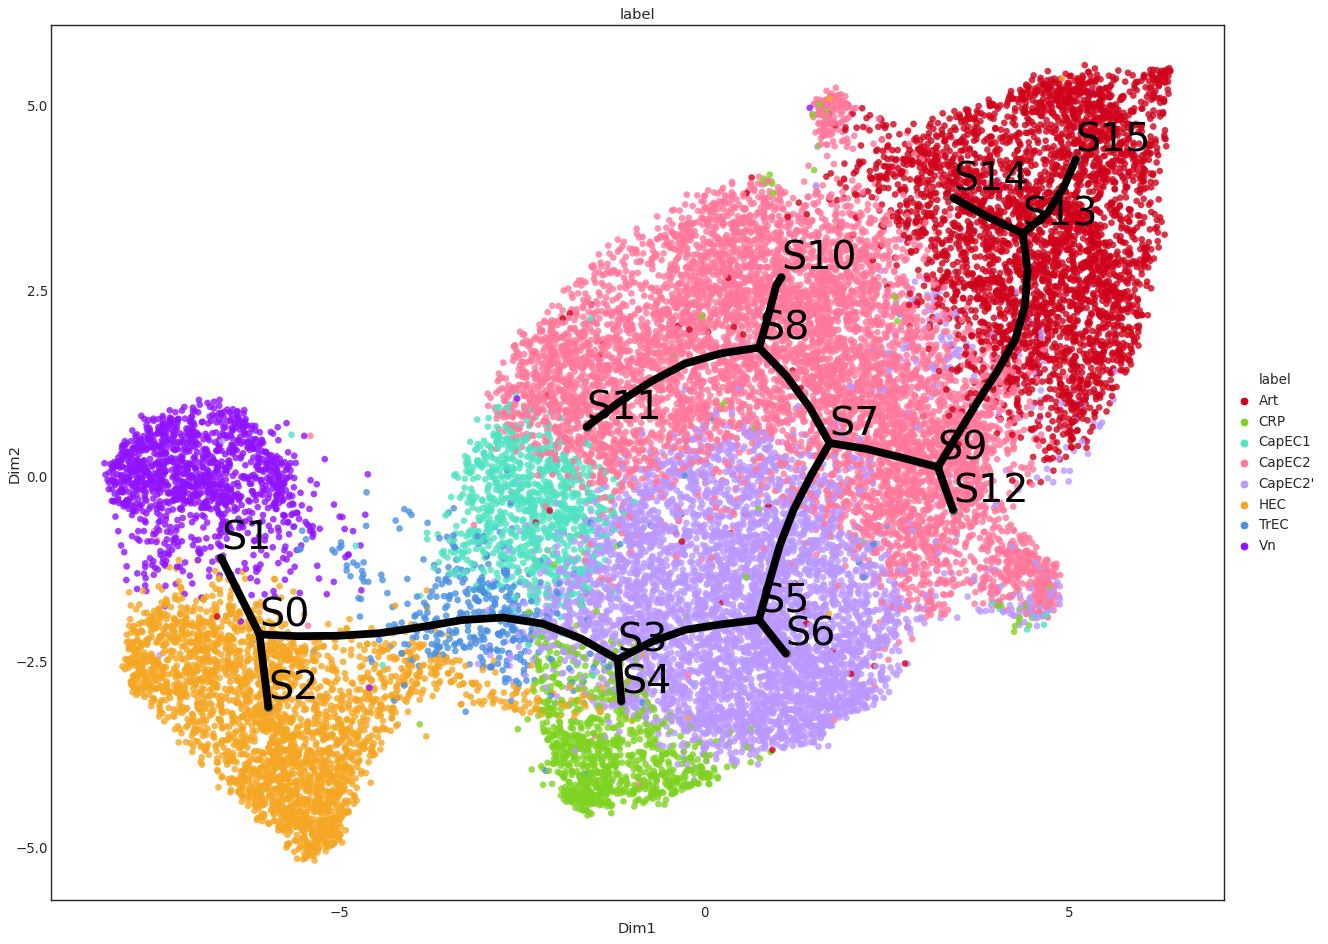

In [8]:
# Plot
st.plot_dimension_reduction(
    adata,color=['label'],
    n_components=2,
    show_graph=True,
    show_text=True,
    save_fig=True,
    line_width=7,
    text_fontsize=3,
    fig_path=f'{"/".join(Fig2["a"].split(f"/")[:-1])}',
    fig_name=f'{Fig2["a"].split(f"/")[-1]}.labels.pdf'
)

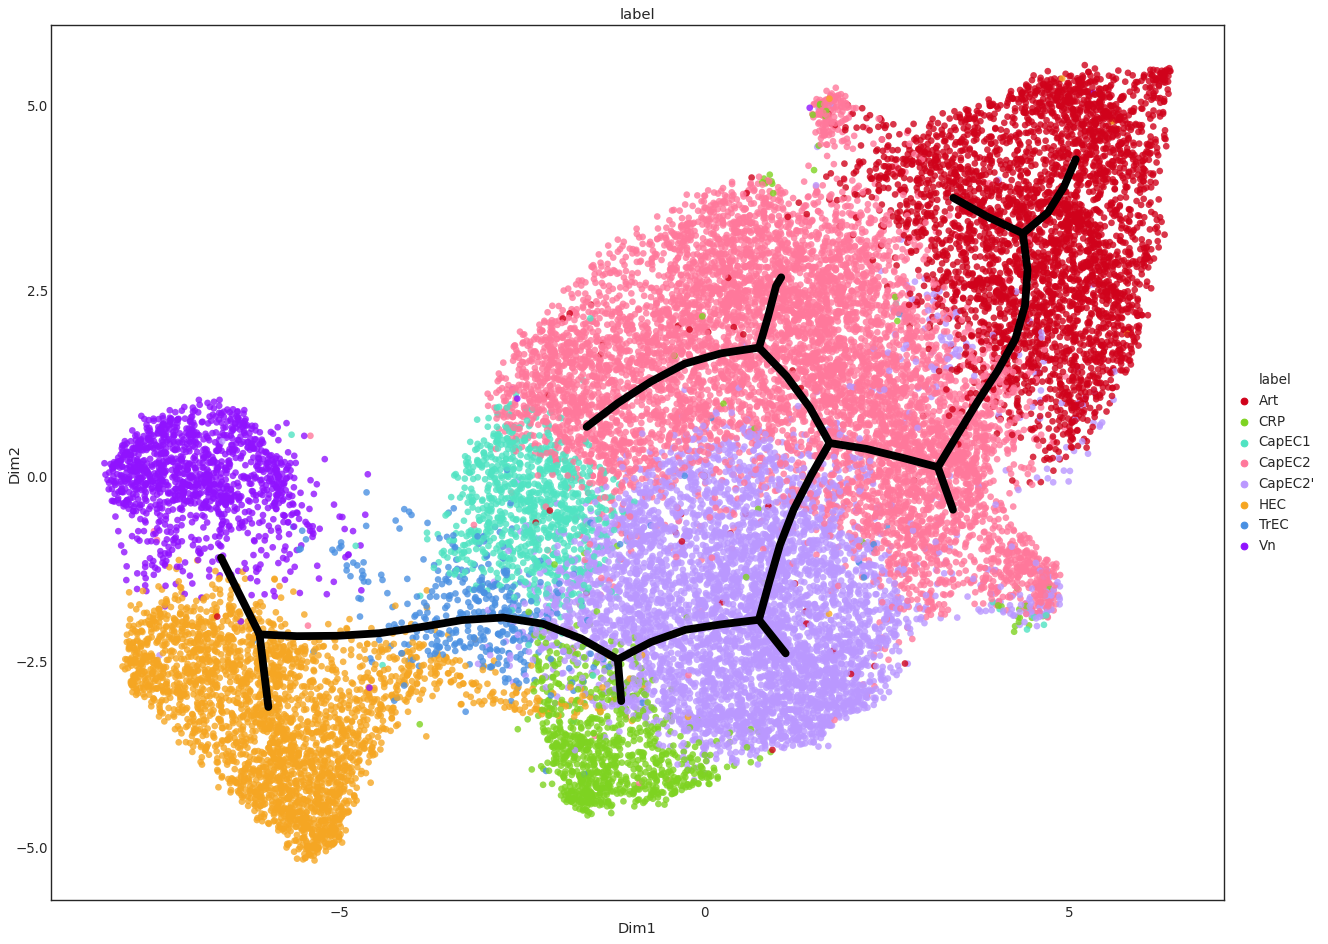

In [9]:
st.plot_dimension_reduction(
    adata,color=['label'],
    n_components=2,
    show_graph=True,
    show_text=False,
    save_fig=True,
    line_width=7,
    fig_path=f'{"/".join(Fig2["a"].split(f"/")[:-1])}',
    fig_name=f'{Fig2["a"].split(f"/")[-1]}.pdf'
)

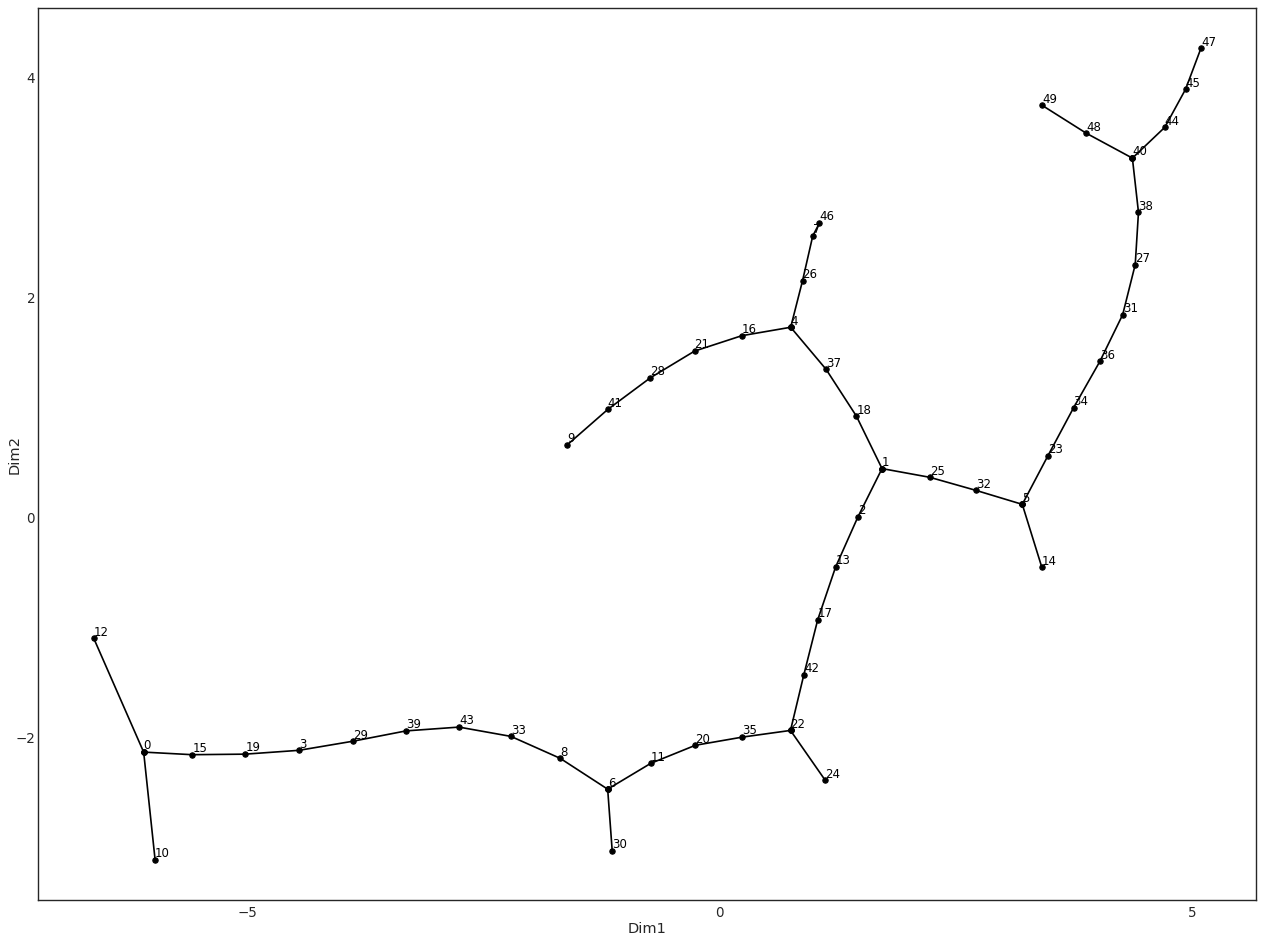

In [10]:
st.plot_branches(
    adata,
    show_text=True
)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1332: MatplotlibDeprecationWarning: MaxNLocator.set_params got an unexpected parameter: fontsize


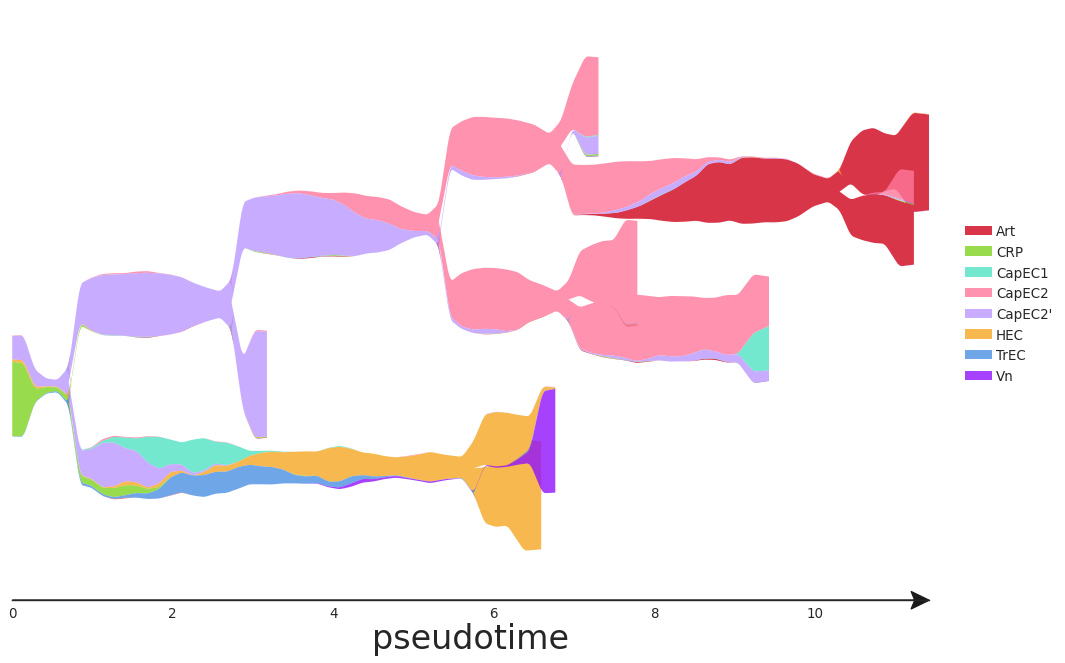

In [11]:
st.plot_stream(
    adata,
    root='S4',
    color=['label'],
    dist_scale=2.0,
    factor_num_win=1.5,
    log_scale=True,
    # preference=['S2', 'S5', 'S9', 'S12', 'S0', 'S3', 'S7', 'S11', 'S15', 'S16'],
    fig_size=(14,9),
    save_fig=True,
    fig_path=f'{"/".join(Fig2["b"].split(f"/")[:-1])}',
    fig_name=f'{Fig2["b"].split(f"/")[-1]}.pdf',
    fontsize=30
)

In [12]:
with open("Stream/adata_wnn_1.pkl", "wb") as tf:
    pickle.dump(adata, tf)

# 4. CRP-Vn cells (Fig2(c, e))

## 4.1. Overwrite coordinate with data from Monocle

In [ ]:
# Load 10x data (combined filtered 10x data)
adata=st.read(
    file_name='ALL/outs/filtered_feature_bc_matrix/matrix.rev.6-7-8-9.mtx',
    file_feature='ALL/outs/filtered_feature_bc_matrix/features.rev.6-7-8-9.tsv',
    file_sample='ALL/outs/filtered_feature_bc_matrix/barcodes.rev.6-7-8-9.tsv',
    file_format='mtx',workdir='./stream_result_CRP-Vn'
)

# Add gene name for the following analysis
adata.var.index = adata.var[1].values

# Avoid duplicated names
adata.var_names_make_unique()

# Save
st.write(adata, file_name='stream_result.pkl')

In [13]:
# Load from cache
adata = st.read('./stream_result_CRP-Vn/stream_result.pkl')

Working directory is already specified as './stream_result_CRP-Vn' 
To change working directory, please run set_workdir(adata,workdir=new_directory)


In [14]:
# Load
df = pd.read_csv("Seurat/out/coordinate(wnn)_subset_by_Seurat.v2.csv", index_col=0)
df.index = [f'{b.split(f"_")[1]}_1' if b[:3]=='pln' else f'{b.split(f"_")[1]}_2' if b[:3]=='mln' else f'{b.split(f"_")[1]}_3' for b in df.index.tolist()]

# Coordinate
data = np.array([df.loc[b, :].tolist()  if b in df.index.tolist() else [0, 0] for b in adata.obs.index.tolist()])
data = data.astype("float32")

# Overwrite
st.dimension_reduction(adata, method='se', feature='top_pcs', n_components=4, n_neighbors=15, n_jobs=6)
adata.obsm["X_vis_umap"] = data
adata.obsm["X_vis"] = data

# Save
st.write(adata, file_name='stream_result_wnn.pkl')

feature top_pcs is being used ...
6 cpus are being used ...


## 4.2. Trajectory inference & Stream plot

In [59]:
# Load from cache
adata = st.read('./stream_result_CRP-Vn/stream_result_wnn.pkl')

Working directory is already specified as './stream_result_CRP-Vn' 
To change working directory, please run set_workdir(adata,workdir=new_directory)


In [60]:
st.seed_elastic_principal_graph(adata,n_clusters=13,use_vis=True)

Seeding initial elastic principal graph...
Clustering...
K-Means clustering ...
The number of initial nodes is 13
Calculatng minimum spanning tree...
Number of initial branches: 4


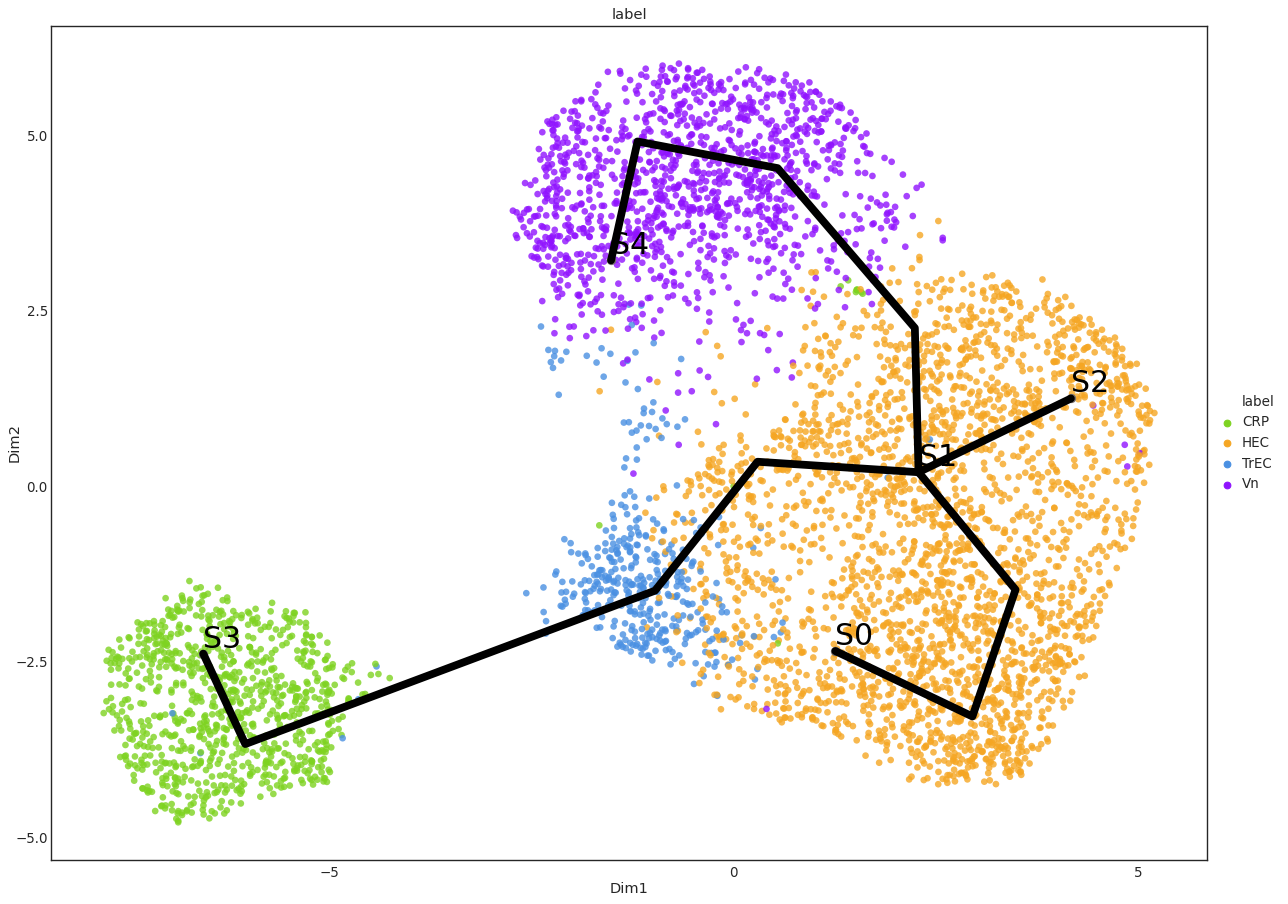

In [46]:
st.plot_dimension_reduction(
    adata,color=['label'],
    n_components=2,
    show_graph=True,
    show_text=True,
    save_fig=True,
    line_width=7,
    text_fontsize=1,
    fig_path=f'{"/".join(Fig2["c"].split(f"/")[:-1])}',
    fig_name=f'{Fig2["c"].split(f"/")[-1]}.labels.pdf'
)

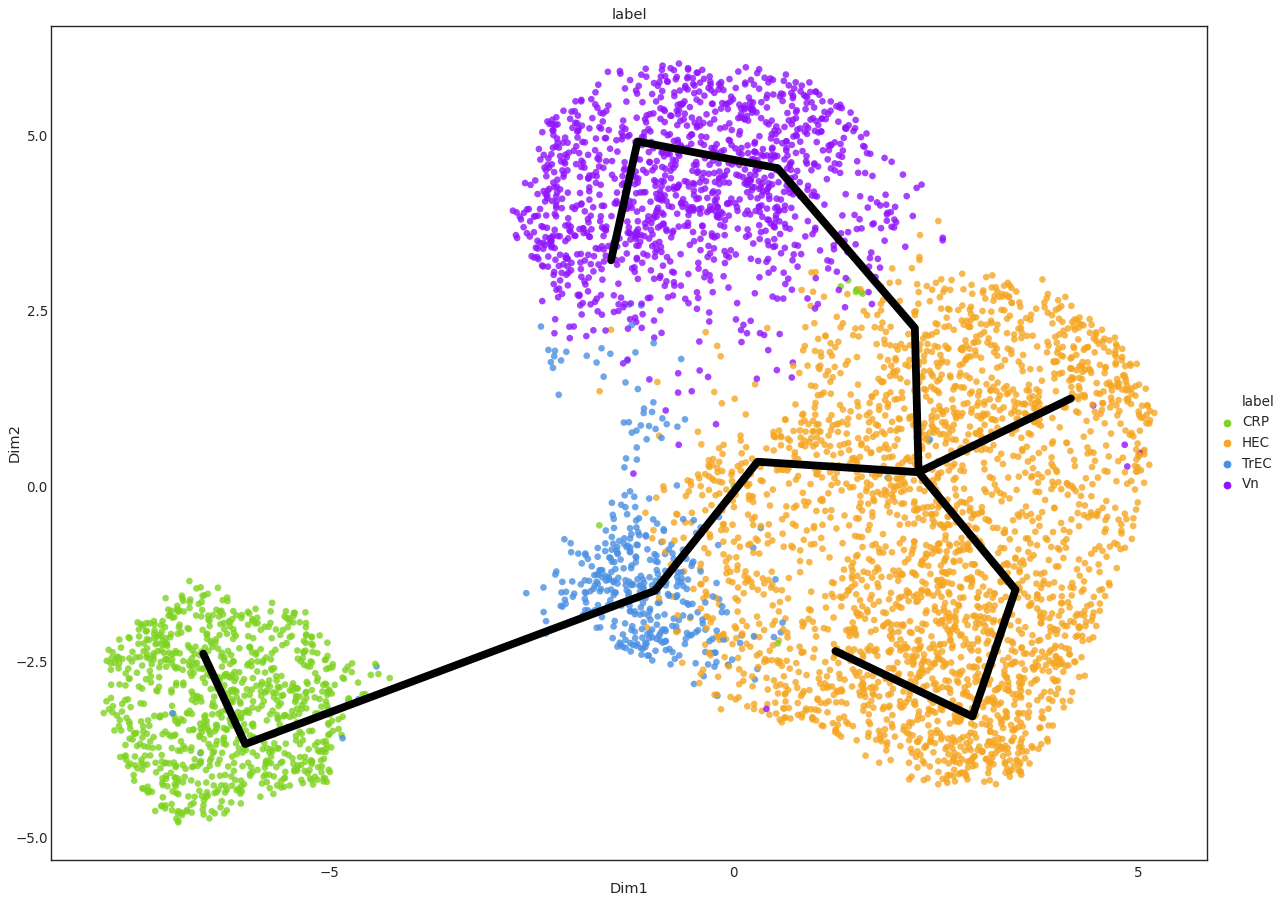

In [47]:
st.plot_dimension_reduction(
    adata,color=['label'],
    n_components=2,
    show_graph=True,
    show_text=False,
    save_fig=True,
    line_width=7,
    fig_path=f'{"/".join(Fig2["c"].split(f"/")[:-1])}',
    fig_name=f'{Fig2["c"].split(f"/")[-1]}.pdf'
)

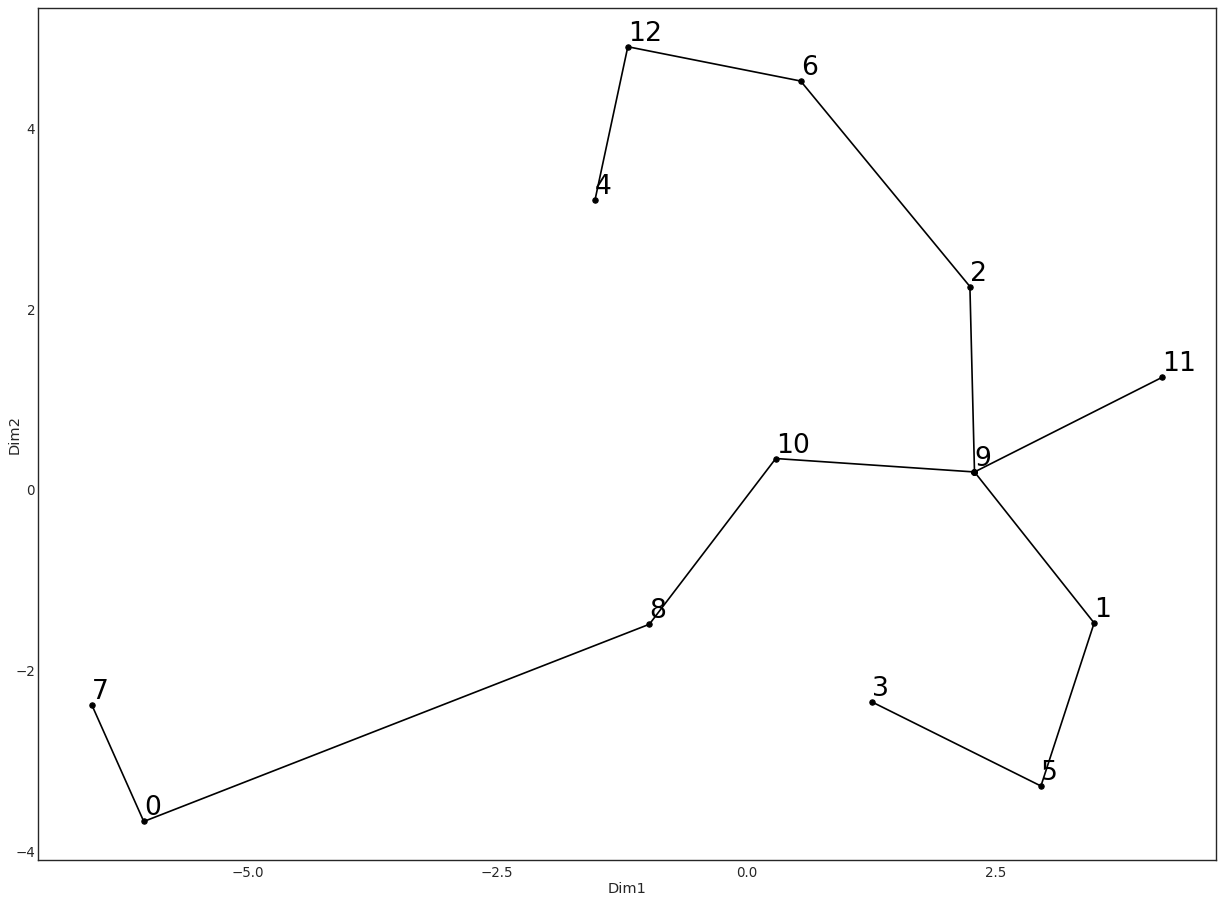

In [48]:
st.plot_branches(
    adata,
    show_text=True
)

/opt/conda/lib/python3.7/site-packages/ipykernel_launcher.py:1332: MatplotlibDeprecationWarning: MaxNLocator.set_params got an unexpected parameter: fontsize


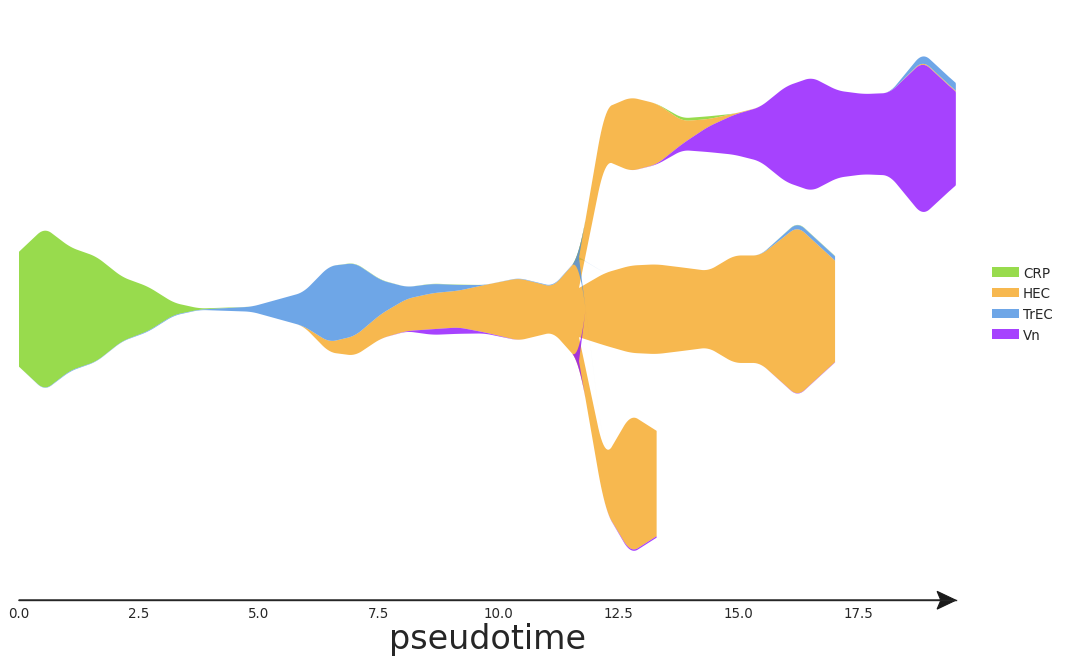

In [49]:
st.plot_stream(
    adata,
    root='S3',
    color=['label'],
    dist_scale=1.0,
    factor_num_win=1.5,
    fig_size=(14,9),
    save_fig=True,
    fig_path=f'{"/".join(Fig2["e"].split(f"/")[:-1])}',
    fig_name=f'{Fig2["e"].split(f"/")[-1]}.pdf',
    fontsize=30
)

In [41]:
with open("Stream/adata_wnn_3.pkl", "wb") as tf:
    pickle.dump(adata, tf)

In [ ]:
with open("Stream/adata_wnn_3.pkl", "rb") as tf:
    adata = pickle.load(tf)

# 5. Change in expression along with trajectory

## 5.1. Constants and functions

In [65]:
epg = adata.uns['epg']
flat_tree = adata.uns['flat_tree']
ft_node_pos = nx.get_node_attributes(flat_tree,'pos')
ft_node_label = nx.get_node_attributes(flat_tree,'label')
epg_node_pos = nx.get_node_attributes(epg,'pos')

In [66]:
def get_x(
    edge_is,
    start,
    n_interval,
    flat_tree=flat_tree,
    epg_node_pos=epg_node_pos
):
    b = np.empty((0, 2))
    endpoint = -1
    for edge_i in edge_is:
        # order of edge
        nodes = flat_tree.edges[edge_i]['nodes']
        if endpoint != -1:
            if nodes[-1] == endpoint:
                nodes = nodes[::-1]
                b = np.concatenate([b, np.array([epg_node_pos[i] for i in flat_tree.edges[edge_i]['nodes'][::-1]])])
            else:
                b = np.concatenate([b, np.array([epg_node_pos[i] for i in flat_tree.edges[edge_i]['nodes']])])
        else:
            if nodes[-1] == start:
                nodes = nodes[::-1]
                b = np.concatenate([b, np.array([epg_node_pos[i] for i in flat_tree.edges[edge_i]['nodes'][::-1]])])
            else:
                b = np.concatenate([b, np.array([epg_node_pos[i] for i in flat_tree.edges[edge_i]['nodes']])])
        endpoint = nodes[-1]

    x = [0]        
    for i in range(len(b) - 1):
        d = ((b[i+1][0] - b[i][0]) ** 2 + (b[i+1][1] - b[i][1]) ** 2) ** (1/2)
        x.append(d + x[-1])
        
    xd = []
    for i in range(len(x)-1):
        if x[i+1] == x[i]:
            xd += [x[i]]
        else:
            unit = (x[i+1] - x[i]) / (n_interval + 1)
            l = [x[i]] + [x[i] + unit * (j + 1) for j in range(n_interval - 1)]
            xd += l
    xd += [x[-1]]
        
    return xd

In [67]:
def get_dist(pos_in, adata=adata):
    return [((c[0]-pos_in[0])**2 + (c[1]-pos_in[1])**2)**(1/2) for c in adata.obsm["X_vis_umap"]]


def get_idxes(tissue_n, adata=adata):
    bs = adata.obs.index.tolist()
    idxes = [i for i in range(len(bs)) if int(bs[i][-1]) in tissue_n]
    return idxes


def get_idx(gene):
    gs = adata.var.index.tolist()
    return [i for i in range(len(gs)) if gs[i] == gene][0]


def get_expressions(gene, tissue_n):
    idx = get_idx(gene)
    idxes = get_idxes(tissue_n)
    return adata.X[idxes, idx]


def calc_integrated_expression_mean(pos_in, cutoff, gene, tissue_n):
    dists = get_dist(pos_in)
    idxes = get_idxes(tissue_n)
    dists = [dists[i] for i in idxes]
    coefs = [1 if d <= cutoff else 0 for d in dists]
    exps = get_expressions(gene, tissue_n)
    exps = [v for c, v in zip(coefs, exps) if c == 1]
    coefs = [c for c in coefs if c == 1]
    v = [exps[i] * coefs[i] for i in range(len(exps))]
    m = np.mean(v) if len(exps) != 0 else 0
    s = np.std(v) if len(exps) != 0 else 0
    # res =  np.log(m) if m > 0 else -2.5
    return m, s


def get_integrated_expressions(
    edge_i,
    sigma,
    gene,
    tissue_n,
    flg,
    n_interval,
    flat_tree=flat_tree,
    epg_node_pos=epg_node_pos
):
    # coordinates
    if flg == 0:
        bip = np.array([epg_node_pos[i] for i in flat_tree.edges[edge_i]['nodes']])
    else:
        bip = np.array([epg_node_pos[i] for i in flat_tree.edges[edge_i]['nodes'][::-1]])
        
    # interval
    bipd = []
    for i in range(len(bip)-1):
        x_unit = (bip[i+1][0] - bip[i][0]) / (n_interval + 1)
        y_unit = (bip[i+1][1] - bip[i][1]) / (n_interval + 1)
        l = [bip[i]] + [[bip[i][0]+x_unit*(j+1), bip[i][1]+y_unit*(j+1)] for j in range(n_interval - 1)]
        bipd += l
    bipd += [bip[-1]]
    
    return [calc_integrated_expression_mean(pos, sigma, gene, tissue_n) for pos in bipd]

In [68]:
def get_label_position(edge_is, start, n_interval, flat_tree=flat_tree, ft_node_label=ft_node_label):
    edge_c = []
    endpoint = -1
    for edge_i in edge_is:
        # order of edge
        nodes = flat_tree.edges[edge_i]['nodes']
        if endpoint != -1:
            if nodes[-1] == endpoint:
                nodes = nodes[::-1]
                edge_c += flat_tree.edges[edge_i]['nodes'][::-1]
            else:
                edge_c += flat_tree.edges[edge_i]['nodes']                
        else:
            if nodes[-1] == start:
                nodes = nodes[::-1]
                edge_c += flat_tree.edges[edge_i]['nodes'][::-1]
            else:
                edge_c += flat_tree.edges[edge_i]['nodes']                
        endpoint = nodes[-1]

    edge_cd = []
    for i in range(len(edge_c)-1):
        if edge_c[i+1] == edge_c[i]:
            edge_cd += [edge_c[i]]
        else:
            l = [edge_c[i]] + [-1 for j in range(n_interval - 1)]
            edge_cd += l
    edge_cd += [edge_c[-1]]
        
    labels = {}
    for i, e in enumerate(edge_cd):
        if e in ft_node_label.keys():
            labels[i] = ft_node_label[e]
            
    return labels

In [78]:
def plot_integrated_expressions(
    gene,
    filename,
    sigma = 1.5,
    edge_iss = [[(7, 9), (3, 9)], [(7, 9), (9, 11)]],
    tissue_ns = [[1], [3]],
    start = 7,
    colors = ["green", "red"],
    legends = ["PLN", "PP"],
    n_interval = 10,
    flat_tree=flat_tree,
    show_nodename=True,
    fontsize=40,
    nodename_fontsize=20,
    y_max=1,
):
    genes = [gene, gene]
    title = gene
    
    # bokeh graph
    p = figure(width=900, height=350, tools=["save"])
    p.title.text = f"{title} expression."
    p.xgrid.grid_line_alpha = 0
    p.ygrid.grid_line_alpha = 0
    p.xaxis.axis_label_text_font_size = f'{fontsize}px'
    p.xaxis.major_label_text_font_size = f'{fontsize}px'
    p.yaxis.axis_label_text_font_size = f'{fontsize}px'
    p.yaxis.major_label_text_font_size = f'{fontsize}px'
    p.y_range=Range1d(0, y_max)
    
    for i, edge_is in enumerate(edge_iss):
        x = get_x(edge_is, start, n_interval)
        m = []
        s = []
        upper = []
        lower = []
        endpoint = -1
        flg = 0
        for edge_i in edge_is:
            
            # order of edge
            nodes = flat_tree.edges[edge_i]['nodes']
            if endpoint != -1:
                if nodes[-1] == endpoint:
                    nodes = nodes[::-1]
                    flg = 1
                else:
                    flg = 0
            else:
                if nodes[-1] == start:
                    nodes = nodes[::-1]
                    flg = 1
                else:
                    flg = 0
            endpoint = nodes[-1]
            
            res = get_integrated_expressions(edge_i, sigma, genes[i], tissue_ns[i], flg, n_interval)
            m_ = [v[0] for v in res]
            s_ = [v[1] for v in res]
            upper += [m_[i] + s_[i] / 5 for i in range(len(m_))]
            lower += [m_[i] - s_[i] / 5 for i in range(len(m_))]
            m += m_
            s += s_
            
        source = ColumnDataSource(data=dict(x=x, m=m, lower=lower, upper=upper))
        p.line("x", "m", color=colors[i], line_width=2, source=source, legend_label=legends[i])
        band = Band(base="x", lower="lower", upper="upper", source=source, fill_alpha=0.1, fill_color=colors[i], line_color=colors[i])
        p.add_layout(band)

        labels = get_label_position(edge_is, start, n_interval)
        ks = labels.keys()
        x_ = [x[k] for k in ks]
        y_ = [m[k]+0.25 for k in ks]
        t_ = [labels[k] for k in ks]
        source = ColumnDataSource(data=dict(x=x_, y=y_, t=t_))
        
        if show_nodename:
            p.text(
                x='x', y='y', text='t',
                text_font_size=str(nodename_fontsize) + "px",
                text_align='right',
                text_baseline='middle',
                text_font_style='bold',
                text_color='black',
                source=source
            )        
        
        p.add_layout(p.legend[0], "right")
    
    # Save
    # p.background_fill_color = None
    # p.border_fill_color = None
    # export_png(p, filename=filename)
    
    # Show
    output_notebook()
    show(p)

## 5.2. Plots

In [91]:
plot_integrated_expressions('Chst4', f'{Fig2["f"]}.Chst4.png', n_interval = 3, sigma = 5, show_nodename=False, y_max=5)

Loading BokehJS ...

In [92]:
plot_integrated_expressions('Fut7', f'{Fig2["f"]}.Fut7.png', n_interval = 3, sigma = 5, show_nodename=False, y_max=6)

Loading BokehJS ...

In [93]:
plot_integrated_expressions('Gcnt1', f'{Fig2["f"]}.Gcnt1.png', n_interval = 3, sigma = 5, show_nodename=False, y_max=7)

Loading BokehJS ...

In [94]:
plot_integrated_expressions('Glycam1', f'{Fig2["f"]}.Glycam1.png', n_interval = 3, sigma = 5, show_nodename=False, y_max=15)

Loading BokehJS ...

In [99]:
plot_integrated_expressions('Madcam1', f'{Fig2["f"]}.Madcam1.png', n_interval = 3, sigma = 5, show_nodename=False, y_max=12)

Loading BokehJS ...

# 6. Change in peak intensity along with trajectory

## 6.1. Functions

In [101]:
def get_intensity(tissue_n, chr_start_end='chr8-110021000-110025000'):
    # Input regions
    c, s, e = chr_start_end.split(f'-')
    s, e = int(s), int(e)
    # Select regions
    tissue = "PLN" if tissue_n == 1 else "MLN" if tissue_n == 2 else "PP"
    peaks = [l.rstrip().split(f'-') for l in open(f'Stream/240401_PLN_atac.index.csv').readlines()]
    peaks = [[li[0], int(li[1]), int(li[2]), i] for i, li in enumerate(peaks)]    
    peaks = [li for li in peaks if li[0]==c]
    peaks = [li for li in peaks if s <= li[1] <= e]
    # peaks = ['-'.join(li[:3]) for li in peaks]
    idxes = [li[3] for li in peaks]
    # Load
    target_lines = []
    for idx in idxes:
        target_lines.append([float(v) for v in linecache.getline(f"Stream/240401_{tissue}_atac.csv", idx+1).rstrip("\n").split(f',')[1:]])
    return np.array(target_lines).mean(axis=0).T


def calc_integrated_intensity_mean(pos_in, cutoff, gene, tissue_n):
    dists = get_dist(pos_in)
    idxes = get_idxes(tissue_n)
    dists = [dists[i] for i in idxes]
    coefs = [1 if d <= cutoff else 0 for d in dists]
    exps = get_intensity(tissue_n, chr_start_end=gene)
    exps = [v for c, v in zip(coefs, exps) if c == 1]
    coefs = [c for c in coefs if c == 1]
    v = [exps[i] * coefs[i] for i in range(len(exps))]
    m = np.mean(v) if len(exps) != 0 else 0
    s = np.std(v) if len(exps) != 0 else 0
    # res =  np.log(m) if m > 0 else -2.5
    return m, s


def get_integrated_intensity(
    edge_i,
    sigma,
    gene,
    tissue_n,
    flg,
    n_interval,
    flat_tree=flat_tree,
    epg_node_pos=epg_node_pos
):
    # coordinates
    if flg == 0:
        bip = np.array([epg_node_pos[i] for i in flat_tree.edges[edge_i]['nodes']])
    else:
        bip = np.array([epg_node_pos[i] for i in flat_tree.edges[edge_i]['nodes'][::-1]])
        
    # interval
    bipd = []
    for i in range(len(bip)-1):
        x_unit = (bip[i+1][0] - bip[i][0]) / (n_interval + 1)
        y_unit = (bip[i+1][1] - bip[i][1]) / (n_interval + 1)
        l = [bip[i]] + [[bip[i][0]+x_unit*(j+1), bip[i][1]+y_unit*(j+1)] for j in range(n_interval - 1)]
        bipd += l
    bipd += [bip[-1]]
    
    return [calc_integrated_intensity_mean(pos, sigma, gene, tissue_n) for pos in bipd]

In [104]:
def plot_integrated_intensity(
    gene,
    filename,
    sigma = 1.5,
    edge_iss = [[(7, 9), (3, 9)], [(7, 9), (9, 11)]],
    tissue_ns = [[1], [3]],
    start = 7,
    colors = ["green", "red"],
    legends = ["PLN", "PP"],
    n_interval = 10,
    flat_tree=flat_tree,
    show_nodename=True,
    fontsize=40,
    nodename_fontsize=20,
    y_max=1,
    is_PLN=False,
    is_PP=False
):
    genes = [gene, gene]
    title = gene
    
    # bokeh graph
    p = figure(width=900, height=350, tools=["save"])
    p.title.text = f"{title} expression."
    p.xgrid.grid_line_alpha = 0
    p.ygrid.grid_line_alpha = 0
    p.xaxis.axis_label_text_font_size = f'{fontsize}px'
    p.xaxis.major_label_text_font_size = f'{fontsize}px'
    p.yaxis.axis_label_text_font_size = f'{fontsize}px'
    p.yaxis.major_label_text_font_size = f'{fontsize}px'
    p.y_range=Range1d(0, y_max)

    for i, edge_is in enumerate(edge_iss):
        x = get_x(edge_is, start, n_interval)
        m = []
        s = []
        upper = []
        lower = []
        endpoint = -1
        flg = 0
        for edge_i in edge_is:
            
            # order of edge
            nodes = flat_tree.edges[edge_i]['nodes']
            if endpoint != -1:
                if nodes[-1] == endpoint:
                    nodes = nodes[::-1]
                    flg = 1
                else:
                    flg = 0
            else:
                if nodes[-1] == start:
                    nodes = nodes[::-1]
                    flg = 1
                else:
                    flg = 0
            endpoint = nodes[-1]
            
            res = get_integrated_intensity(edge_i, sigma, genes[i], tissue_ns[i], flg, n_interval)
            if i == 0 and is_PLN:
                m_ = [v[0]*6 for v in res]
                s_ = [v[1] for v in res]
            elif i ==1 and is_PP:
                m_ = [v[0]*6 for v in res]
                s_ = [v[1] for v in res]
            else:
                m_ = [v[0] for v in res]
                s_ = [v[1] for v in res]
            upper += [m_[i] + s_[i] / 5 for i in range(len(m_))]
            lower += [m_[i] - s_[i] / 5 for i in range(len(m_))]
            m += m_
            s += s_
            
        source = ColumnDataSource(data=dict(x=x, m=m, lower=lower, upper=upper))
        p.line("x", "m", color=colors[i], line_width=2, source=source, legend_label=legends[i])
        band = Band(base="x", lower="lower", upper="upper", source=source, fill_alpha=0.1, fill_color=colors[i], line_color=colors[i])
        p.add_layout(band)

        labels = get_label_position(edge_is, start, n_interval)
        ks = labels.keys()
        x_ = [x[k] for k in ks]
        y_ = [m[k]+0.25 for k in ks]
        t_ = [labels[k] for k in ks]
        source = ColumnDataSource(data=dict(x=x_, y=y_, t=t_))

        if show_nodename:
            p.text(
                x='x', y='y', text='t',
                text_font_size=str(nodename_fontsize) + "px",
                text_align='right',
                text_baseline='middle',
                text_font_style='bold',
                text_color='black',
                source=source
            )        
        
        p.add_layout(p.legend[0], "right")
    
    # Save
    # p.background_fill_color = None
    # p.border_fill_color = None
    # export_png(p, filename=filename)

    # Show
    output_notebook()
    show(p)

## 6.2. Plots

In [110]:
# Chst4
plot_integrated_intensity(
    'chr8-110021000-110045000', f'{Fig2["g"]}.Chst4.png',
    n_interval=3, sigma=5, show_nodename=False,
    y_max=0.25, is_PLN=True
)

Loading BokehJS ...

In [111]:
# Fut7
plot_integrated_intensity(
    'chr2-25420000-25430000', f'{Fig2["g"]}.Fut7.png',
    n_interval=3, sigma=5, show_nodename=False,
    y_max=0.75, is_PLN=True
)

Loading BokehJS ...

In [112]:
# Gcnt1
plot_integrated_intensity(
    'chr19-17338000-17360000', f'{Fig2["g"]}.Gcnt1.png',
    n_interval=3, sigma=5, show_nodename=False,
    y_max=0.5, is_PLN=True
)

Loading BokehJS ...

In [113]:
# Glycam1
plot_integrated_intensity(
    'chr15-103560000-103567500', f'{Fig2["g"]}.Glycam1.png',
    n_interval=3, sigma=5, show_nodename=False,
    y_max=0.5, is_PLN=True
)

Loading BokehJS ...

In [114]:
# Madcam1
plot_integrated_intensity(
    'chr10-79658000-79665000', f'{Fig2["g"]}.Madcam1.png',
    n_interval=3, sigma=5, show_nodename=False,
    y_max=1, is_PP=True
)

Loading BokehJS ...